# E41 · "Is my child normal?" Distributional regression and growth centile charts

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | The **Fourth Dutch Growth Study** (1996-7): body-mass index of 7,294 Dutch boys aged 0-21, one measurement each (`dbbmi` from the CRAN package `gamlss.data`, read straight from the R data file) |
| **You will learn** | **Distributional regression** (GAMLSS): every parameter of the outcome distribution - median, spread, skewness, tails - is a smooth function of age · why a mean-only regression gives wrong **centiles** even when its mean is right · **Bayesian P-splines** (B-spline basis + second-order random-walk prior) and why the *centred* form samples far better with 7,000 observations · Cole & Green's **LMS method** as the **Box-Cox Cole-Green (BCCG)** distribution, its log-density written by hand and checked (integration, known special cases, simulation) · a fourth parameter for the tails: the **Box-Cox t** · the classic age-bin LMS fit by maximum likelihood next to the Bayesian curves · **worm plots** (detrended Q-Q by age band), centile coverage tables and LOO · uncertainty on the **centile lines themselves**, and where it is large · explaining it to everyone: a blurred growth chart, "of 100 boys his age", 20 equally likely boys, an animation of the distribution growing up, a hover chart |

## The question, in one paragraph

At every check-up a nurse weighs and measures a child and puts a dot on a growth chart, and
parents ask the obvious question: **is my child normal?** The chart answers with lines: "3 in
100 boys of this age are below this line, 97 in 100 are below that one". But where do those
lines come from? Someone measured thousands of children of every age and worked out, age by
age, not just the *average* but the whole spread - including the fact that a few children are
much heavier than average while hardly anyone is much lighter. The lines are estimates too, so
they are a little uncertain, more so at ages where few children were measured. This notebook
draws a body-mass-index chart for Dutch boys from the original survey data, shows how the
simple approach puts the wrong children outside the lines, and shows how sure we can be of
each line - and of where one example boy sits on it.

## The technical plan

Ordinary regression models the **mean** of the outcome and treats everything else as noise
with a constant spread. A growth chart needs much more: the 3rd and 97th centiles depend on
the spread and the *shape* of the distribution at every age. **Generalised additive models for
location, scale and shape** (GAMLSS; Rigby & Stasinopoulos 2005, *Applied Statistics*) let
every parameter of the distribution depend smoothly on covariates; the Bayesian version is
often called **distributional regression** (Klein, Kneib, Lang & Sohn 2015, *Annals of Applied
Statistics*; Umlauf, Klein & Zeileis 2018, *JCGS*, the `bamlss` package). The growth-chart
special case is Cole & Green's **LMS method** (1992, *Statistics in Medicine*): at each age,
a Box-Cox power **L** makes the data normal, with median **M** and coefficient of variation
**S** - three smooth curves. The WHO Child Growth Standards were built with the same family
of distributions (Box-Cox-type, with a fourth parameter for the tails where needed).

We fit four models of increasing ambition, each with its parameters as P-splines in age:
(A) normal with a smooth mean and constant spread; (B) normal with a smooth spread too;
(C) BCCG = LMS; (D) Box-Cox t, which adds heavier tails. We judge them by what matters for a
chart: does the "3 in 100 below" line actually have 3 in 100 below it at every age?

In [1]:
import bz2
import gzip
import json
import logging
import lzma
import struct
import time
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from IPython.display import HTML
from matplotlib import animation
from matplotlib.patches import Circle, Ellipse, FancyBboxPatch
from scipy import integrate, optimize, stats
from scipy.interpolate import BSpline
from scipy.special import ndtr, ndtri

from pymc_challenges import data

RANDOM_SEED = 1997
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
pio.renderers.default = "plotly_mimetype+notebook_connected"
logging.getLogger("pymc").setLevel(logging.WARNING)

# One colour per model, a sequential ramp for the centiles (3rd ... 97th), grey for data.
C_NORM, C_HET, C_BCCG, C_BCT, GREY, INK = "#d6452a", "#e8b422", "#2a78d6", "#7a3fb8", "#8a8a86", "#222222"
CENTILES = np.array([0.03, 0.10, 0.50, 0.90, 0.97])
C_RAMP = ["#9ec5f0", "#5a9be0", "#1c4f94", "#5a9be0", "#9ec5f0"]
AGE_TICKS = [0, 0.25, 1, 2, 4, 6, 9, 12, 15, 18, 21]


def age_axis(ax, label=True, ticks=AGE_TICKS):
    """Stretch the first years (cube-root age), but label the axis in years."""
    ax.set_xscale("function", functions=(np.cbrt, lambda x: x**3))
    ax.set_xticks(ticks, [f"{a:g}" for a in ticks])
    ax.set_xlim(0, 21.8)
    if label:
        ax.set_xlabel("age (years; the first years are stretched)")


def ordinal(q):
    n = int(round(q * 100))
    return f"{n}{'rd' if n % 10 == 3 and n != 13 else 'th'}"


def stacked(da):
    """(chain, draw, ...) -> (sample, ...) NumPy array."""
    return da.stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()


print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data

The Fourth Dutch Growth Study (Fredriks et al. 2000) measured height, weight and head
circumference of about 14,500 children in the Netherlands in 1996-7; the boys' BMI is
distributed with the R package `gamlss.data` (as `dbbmi`) and is the running example of the
GAMLSS books. It is **cross-sectional**: each boy was measured once, so this is a reference
for "boys of this age", not a record of how any boy grew. We read the R data file directly
with the small XDR reader from E23/E24/E39 (this one is xz-compressed).

In [2]:
def read_rdata(path):
    """Minimal reader for R's XDR serialisation (gzip, bzip2 or xz): named lists, vectors, strings."""
    raw = Path(path).read_bytes()
    buf = (bz2.decompress(raw) if raw[:2] == b"BZ" else
           lzma.decompress(raw) if raw[:6] == b"\xfd7zXZ\x00" else gzip.decompress(raw))
    assert buf[:7] in (b"RDX2\nX\n", b"RDX3\nX\n"), "not an XDR R data file"
    pos, refs = 7, []

    def i32():
        nonlocal pos
        pos += 4
        return struct.unpack(">i", buf[pos - 4:pos])[0]

    def item():
        nonlocal pos
        flags = i32()
        kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
        if kind == 254:                                     # NULL
            return None
        if kind == 255:                                     # reference to an earlier symbol
            return refs[(flags >> 8) - 1]
        if kind == 1:                                       # symbol
            refs.append(item())
            return refs[-1]
        if kind == 9:                                       # string
            n = i32()
            pos += max(n, 0)
            return None if n == -1 else buf[pos - n:pos].decode()
        if kind == 2:                                       # pairlist -> dict
            out = {}
            while kind == 2:
                _ = item() if has_attr else None
                tag = item() if has_tag else None
                out[tag] = item()
                flags = i32()
                kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
            return out
        n = i32()
        if kind in (10, 13):                                # logical / integer
            value, pos = np.frombuffer(buf, ">i4", n, pos).astype(int), pos + 4 * n
        elif kind == 14:                                    # double
            value, pos = np.frombuffer(buf, ">f8", n, pos).astype(float), pos + 8 * n
        elif kind in (16, 19):                              # character vector / list
            value = [item() for _ in range(n)]
        else:
            raise NotImplementedError(f"R type {kind}")
        attrs = item() if has_attr else None
        if kind == 19 and attrs and "names" in attrs:
            value = dict(zip(attrs["names"], value))
        return value

    version = i32()
    pos += 8
    if version == 3:
        pos += 4 + struct.unpack(">i", buf[pos:pos + 4])[0]
    return item()


data.describe("dutch_boys_bmi")
boys = pd.DataFrame(read_rdata(data.path("dutch_boys_bmi"))["dbbmi"]).sort_values("age").reset_index(drop=True)
AGE, BMI = boys.age.to_numpy(), boys.bmi.to_numpy()
N = len(boys)
BANDS = [0, 0.5, 2, 5, 9, 13, 17, 22]
BAND_LABELS = ["0-6 mo", "6 mo-2 y", "2-5 y", "5-9 y", "9-13 y", "13-17 y", "17-21 y"]
band = pd.cut(boys.age, BANDS, right=False, labels=BAND_LABELS)
print(f"{N} boys, age {AGE.min():.2f}-{AGE.max():.1f} years, BMI {BMI.min():.1f}-{BMI.max():.1f}")
summary = boys.groupby(band, observed=True).bmi.agg(
    n="size", median="median", p03=lambda v: v.quantile(0.03), p97=lambda v: v.quantile(0.97),
    skew=lambda v: stats.skew(v))
summary.round(2)

# The table already shows the problem. The median BMI rises in the first year (the baby fat),
# falls until about age 6 and rises again through puberty. But the **3rd and 97th percentiles
# are not symmetric around the median**: at 9-13 years the 97th percentile is 6 units above the
# median and the 3rd only 3 below, and the skewness (last column) jumps from
# under 0.5 before age 5 to over 1 at school age. The survey also sampled ages unevenly: many
# babies and teenagers, few boys aged 4-9.

dutch_boys_bmi: R data file (xz-compressed XDR): a data frame `dbbmi` of 7,294 Dutch boys aged 0.03-21.7 years: age (years) and bmi (body-mass index, kg/m^2). Cross-sectional: one measurement per boy.
  source: Fourth Dutch Growth Study 1996-7 (Fredriks et al. 2000, Pediatric Research 47:316-323; Archives of Disease in Childhood 82:107-112), data given by S. van Buuren; as distributed in the CRAN package gamlss.data (Stasinopoulos & Rigby), identical to dbbmi.rda in gamlss.data_6.0-7.tar.gz.
  url:    https://raw.githubusercontent.com/cran/gamlss.data/master/data/dbbmi.rda
7294 boys, age 0.03-21.7 years, BMI 11.2-35.4


,n,median,p03,p97,skew
age,,,,,
0-6 mo,750,15.58,12.77,18.60,0.21
6 mo-2 y,1111,17.15,14.85,19.75,0.44
2-5 y,828,15.94,13.81,18.58,0.46
5-9 y,450,15.68,13.47,20.29,1.42
9-13 y,1427,16.86,14.07,22.82,1.23
13-17 y,1604,19.13,15.51,25.26,1.16
17-21 y,1124,21.21,17.37,27.74,0.80


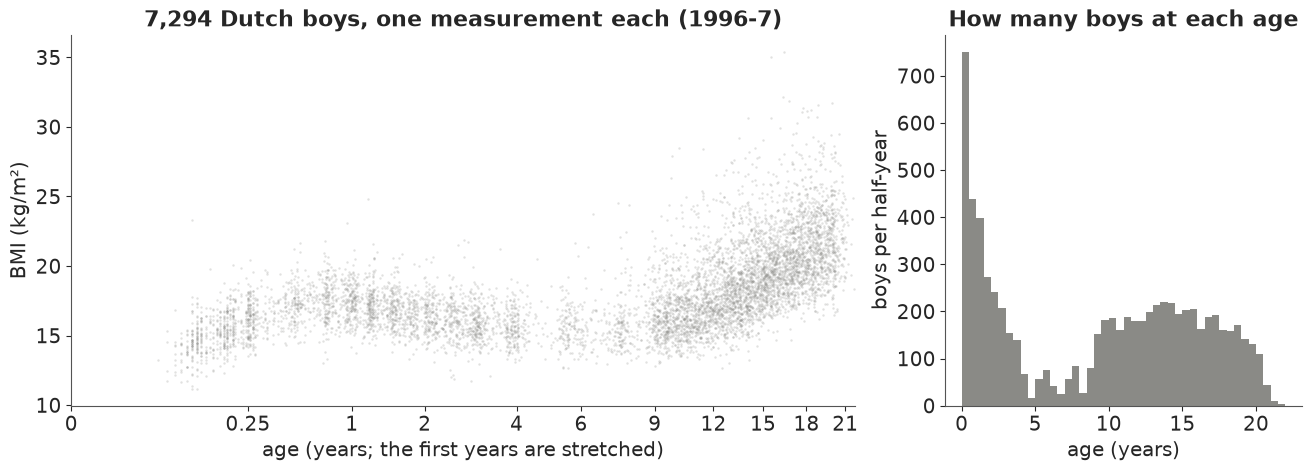

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), width_ratios=[2.2, 1])
ax = axes[0]
ax.scatter(AGE, BMI, s=3, alpha=0.25, color=GREY, lw=0)
age_axis(ax)
ax.set(ylabel="BMI (kg/m²)", title=f"{N:,} Dutch boys, one measurement each (1996-7)")
ax = axes[1]
ax.hist(AGE, bins=np.arange(0, 22.5, 0.5), color=GREY)
ax.set(xlabel="age (years)", ylabel="boys per half-year", title="How many boys at each age");

## 2 · A smooth-curve building block: Bayesian P-splines in age

BMI changes fastest in the first months, so we work in **cube-root age** $t = \text{age}^{1/3}$,
which stretches the first two years (the x-axes above and below do the same). Every
distribution parameter will be a smooth function of $t$ built the same way, as a **Bayesian
P-spline** (Eilers & Marx 1996 for P-splines; Lang & Brezger 2004, *JCGS*, for the Bayesian
form): $f(t) = \sum_k B_k(t)\,\beta_k$ with $K = 16$ cubic B-splines on equally spaced knots,
and a **second-order random walk** prior on the coefficients: $\beta_{k} - 2\beta_{k-1} +
\beta_{k-2} \sim N(0, \tau^2)$. A small $\tau$ means a nearly straight line; the data decide
how wiggly each curve is. We write $\beta = a + b\,k + W z$, where $W$ turns the $K-2$ second
differences $z$ into a path with its constant and linear parts projected out, so the level
$a$, the trend $b$ and the wiggle $z$ are separately identifiable.

The priors are on interpretable scales: log median BMI around log 17 (sd 0.3), log spread
around log 0.1 (a coefficient of variation of 10%, sd 0.5), Box-Cox power around 0 (sd 1). The
prior predictive curves below allow median BMIs from about 9 to 33 and spreads from 2% to 40%
- wide, but nothing absurd.

basis at the data: (7294, 16) | second differences of W_RW2 = identity: True
prior 90% range at age 10: median BMI [ 8.8 32.9], S [0.023 0.407], L [-2.35  2.62]


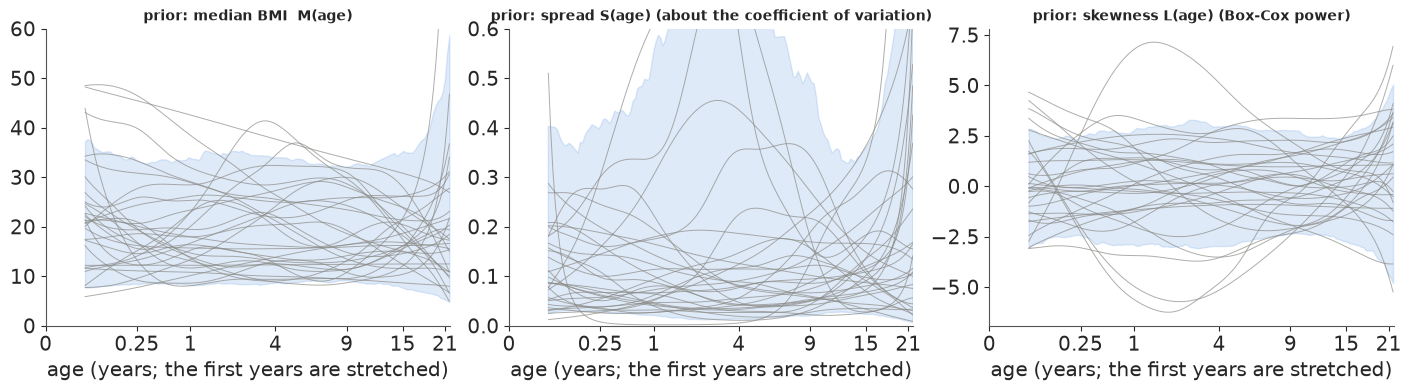

In [4]:
POW = 1 / 3
T_LO, T_HI = 0.0, 22.0**POW
K, DEG = 16, 3
KNOTS = np.r_[[T_LO] * DEG, np.linspace(T_LO, T_HI, K - DEG + 1), [T_HI] * DEG]


def basis(ages):
    """Cubic B-spline basis in cube-root age (rows sum to one)."""
    tt = np.clip(np.asarray(ages, float) ** POW, T_LO, T_HI - 1e-9)
    return BSpline.design_matrix(tt, KNOTS, DEG).toarray()


# Coefficients = intercept + linear trend + a second-order random walk (RW2) with the constant
# and linear parts projected out (so the three pieces are identifiable).
kc = (np.arange(K) - (K - 1) / 2) / np.arange(K).std()
Csum = np.tril(np.ones((K, K)))
C2 = np.vstack([np.zeros((2, K - 2)), (Csum @ Csum)[:K - 2, :K - 2]])  # 2nd differences -> path
X_lin = np.c_[np.ones(K), kc]
W_RW2 = (np.eye(K) - X_lin @ np.linalg.solve(X_lin.T @ X_lin, X_lin.T)) @ C2
B_OBS = basis(AGE)
AGE_GRID = np.linspace(0.02**POW, 21.7**POW, 160) ** 3
B_GRID = basis(AGE_GRID)
print("basis at the data:", B_OBS.shape, "| second differences of W_RW2 = identity:",
      np.allclose(np.diff(W_RW2, 2, axis=0), np.eye(K - 2)))


def smooth(name, a_mu, a_sd, b_sd, tau_sd, centred=True):
    """A smooth function of age on the data rows: B @ (a + b * k + W z), z ~ N(0, tau)."""
    a = pm.Normal(f"{name}_a", a_mu, a_sd)
    b = pm.Normal(f"{name}_b", 0.0, b_sd)
    tau = pm.HalfNormal(f"{name}_tau", tau_sd)
    if centred:
        z = pm.Normal(f"{name}_z", 0.0, tau, dims="rw2_step")
        return pt.dot(B_OBS, a + b * kc + pt.dot(W_RW2, z))
    z_raw = pm.Normal(f"{name}_zraw", 0.0, 1.0, dims="rw2_step")
    return pt.dot(B_OBS, a + b * kc + tau * pt.dot(W_RW2, z_raw))


def curve(idata, name, B=B_GRID):
    """Posterior draws (sample x rows of B) of a smooth function."""
    post = idata.posterior
    a, b = stacked(post[f"{name}_a"]), stacked(post[f"{name}_b"])
    z = stacked(post[f"{name}_z"])
    return (a[:, None] + b[:, None] * kc + z @ W_RW2.T) @ B.T


def prior_curves(a_mu, a_sd, b_sd, tau_sd, n, seed):
    r = np.random.default_rng(seed)
    a, b = r.normal(a_mu, a_sd, n), r.normal(0, b_sd, n)
    tau = np.abs(r.normal(0, tau_sd, n))
    z = r.normal(size=(n, K - 2)) * tau[:, None]
    return (a[:, None] + b[:, None] * kc + z @ W_RW2.T) @ B_GRID.T


PRIORS = {"mu": (np.log(17.0), 0.3, 0.3, 0.1), "sig": (np.log(0.1), 0.5, 0.5, 0.3), "nu": (0.0, 1.0, 1.0, 0.5)}
J10 = np.argmin(np.abs(AGE_GRID - 10))
pri = {k: prior_curves(*v, n=500, seed=RANDOM_SEED + i) for i, (k, v) in enumerate(PRIORS.items())}
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (k, f), tr, lab in zip(axes, pri.items(), [np.exp, np.exp, lambda v: v],
                               ["median BMI  M(age)", "spread S(age) (about the coefficient of variation)",
                                "skewness L(age) (Box-Cox power)"]):
    v = tr(f)
    for s in range(30):
        ax.plot(AGE_GRID, v[s], color=GREY, lw=0.7, alpha=0.7)
    ax.fill_between(AGE_GRID, *np.quantile(v, [0.05, 0.95], axis=0), color=C_BCCG, alpha=0.15)
    age_axis(ax, ticks=[0, 0.25, 1, 4, 9, 15, 21])
    ax.set_title(f"prior: {lab}", fontsize=10)
axes[0].set_ylim(0, 60)
axes[1].set_ylim(0, 0.6)
print("prior 90% range at age 10: median BMI "
      f"{np.quantile(np.exp(pri['mu'][:, J10]), [0.05, 0.95]).round(1)}, S {np.quantile(np.exp(pri['sig'][:, J10]), [0.05, 0.95]).round(3)}, "
      f"L {np.quantile(pri['nu'][:, J10], [0.05, 0.95]).round(2)}");

## 3 · Model A: the mean moves with age, the spread does not

The first model is what most people fit: a smooth mean and normal noise with one standard
deviation. We sample with nutpie and its **low-rank mass matrix** (`nuts={"adaptation":
"low_rank"}`), which adapts to the strong correlations between neighbouring spline
coefficients.

In [5]:
COORDS = {"rw2_step": np.arange(K - 2)}
FITS, TIMES = {}, {}


def fit(model, key, keep=True):
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, nuts={"adaptation": "low_rank"}, progressbar=False)
    TIMES[key] = time.time() - t0
    ss = idata.sample_stats
    free = [v for v in idata.posterior.data_vars if not v.endswith(("_z", "_zraw"))]
    s_all = az.summary(idata, round_to=4)  # round_to=None still rounds to 2 significant figures
    rh, ess = s_all["r_hat"].max(), s_all["ess_bulk"].min()
    print(f"{key}: {TIMES[key]:.0f} s, {int(ss['diverging'].sum())} divergences, max r_hat {rh:.3f}, "
          f"min bulk ESS {ess:.0f}, mean tree depth {float(ss['depth'].mean()):.1f}, "
          f"tuning steps {idata.posterior.attrs.get('tuning_steps')}")
    if keep:
        FITS[key] = idata
    return az.summary(idata, var_names=free, round_to=3)


with pm.Model(coords=COORDS) as m_norm:
    f_mu = smooth("mu", *PRIORS["mu"])
    sd = pm.HalfNormal("sd", 3.0)
    pm.Normal("bmi", mu=pt.exp(f_mu), sigma=sd, observed=BMI)
fit(m_norm, "A: normal, constant sd")

A: normal, constant sd: 3 s, 0 divergences, max r_hat 1.003, min bulk ESS 3947, mean tree depth 2.9, tuning steps 800


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_a,2.776,0.022,2.739,2.811,7235.501,3008.587,1.000,0.0,0.000
mu_b,0.195,0.033,0.142,0.249,7128.644,3038.734,1.001,0.0,0.001
mu_tau,0.068,0.017,0.046,0.099,3947.370,3286.744,1.000,0.0,0.000
sd,2.066,0.018,2.038,2.094,9559.872,3177.789,1.001,0.0,0.000


A: normal, constant sd             
                    % below 3rd % above 97th
0-6 mo                      0.0          0.5
6 mo-2 y                    0.2          0.6
2-5 y                       0.5          1.2
5-9 y                       0.0          3.3
9-13 y                      0.6          5.8
13-17 y                     1.6          6.9
17-21 y                     3.0          7.0
all ages                    1.0          4.2

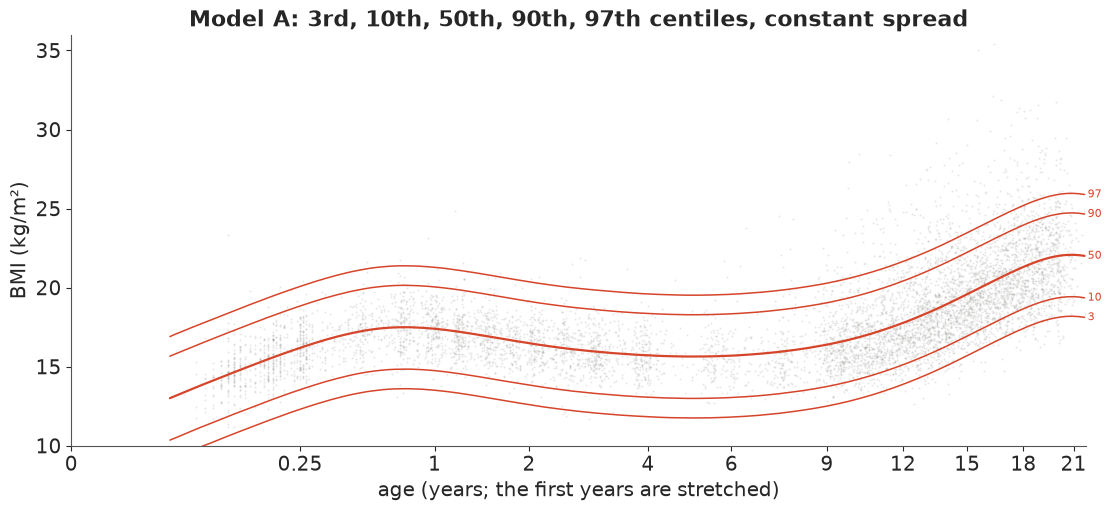

In [6]:
def model_draws(key, idata, B, n=None):
    """Distribution parameters on the rows of B, as (sample x rows) arrays."""
    sl = slice(None) if n is None else np.linspace(0, idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"] - 1, n).astype(int)
    out = {"mu": np.exp(curve(idata, "mu", B))[sl]}
    if key.startswith("A"):
        out["sd"] = np.broadcast_to(stacked(idata.posterior["sd"])[sl, None], out["mu"].shape)
    elif key.startswith("B"):
        out["sd"] = out["mu"] * np.exp(curve(idata, "sig", B))[sl]
    else:
        out["sigma"] = np.exp(curve(idata, "sig", B))[sl]
        out["nu"] = curve(idata, "nu", B)[sl]
        if key.startswith("D"):
            out["tau"] = np.broadcast_to(np.exp(stacked(idata.posterior["log_tau"]))[sl, None], out["mu"].shape)
    return out


def safe_nu(nu):
    return np.where(np.abs(nu) < 1e-6, 1e-6, nu)


def bc_z(y, mu, sigma, nu):
    nu = safe_nu(nu)
    return np.expm1(nu * np.log(y / mu)) / (nu * sigma)


def bc_y(z, mu, sigma, nu):
    nu = safe_nu(nu)
    return mu * np.exp(np.log1p(sigma * nu * z) / nu)


def cdf(key, y, p):
    """Model CDF at y for parameter arrays p (broadcasting)."""
    if "sd" in p:
        return ndtr((y - p["mu"]) / p["sd"])
    z = bc_z(y, p["mu"], p["sigma"], p["nu"])
    if "tau" in p:  # untruncated BCT
        return stats.t.cdf(z, p["tau"])
    b = 1 / (p["sigma"] * np.abs(safe_nu(p["nu"])))
    return np.where(p["nu"] < 0, ndtr(z) / ndtr(b), (ndtr(z) - ndtr(-b)) / ndtr(b))


def ppf(key, q, p):
    """Model quantile (centile) q for parameter arrays p."""
    if "sd" in p:
        return p["mu"] + p["sd"] * ndtri(q)
    if "tau" in p:
        zq = stats.t.ppf(q, p["tau"])
    else:
        b = 1 / (p["sigma"] * np.abs(safe_nu(p["nu"])))
        zq = np.where(p["nu"] < 0, ndtri(q * ndtr(b)), ndtri(1 - (1 - q) * ndtr(b)))
    return bc_y(zq, p["mu"], p["sigma"], p["nu"])


def logpdf(key, y, p):
    if "sd" in p:
        return stats.norm.logpdf(y, p["mu"], p["sd"])
    nu = safe_nu(p["nu"])
    l = np.log(y / p["mu"])
    z = np.expm1(nu * l) / (nu * p["sigma"])
    jac = nu * l - np.log(y) - np.log(p["sigma"])
    if "tau" in p:
        return jac + stats.t.logpdf(z, p["tau"])
    b = 1 / (p["sigma"] * np.abs(nu))
    return jac + stats.norm.logpdf(z) - np.log(ndtr(b))


CENT, PIT = {}, {}


def centiles_and_pit(key):
    idata = FITS[key]
    pg = model_draws(key, idata, B_GRID, n=1000)
    CENT[key] = np.stack([ppf(key, q, pg) for q in CENTILES])          # (centile, sample, age)
    po = model_draws(key, idata, B_OBS, n=400)
    PIT[key] = cdf(key, BMI[None, :], po).mean(axis=0)                # posterior-averaged PIT per boy


def coverage_table(keys):
    rows = {}
    for key in keys:
        pit = pd.Series(PIT[key])
        rows[(key, "% below 3rd")] = (pit < 0.03).groupby(band.to_numpy(), sort=False).mean() * 100
        rows[(key, "% above 97th")] = (pit > 0.97).groupby(band.to_numpy(), sort=False).mean() * 100
    tab = pd.DataFrame(rows).reindex(BAND_LABELS)
    tab.loc["all ages"] = [((PIT[k] < 0.03) if "below" in c else (PIT[k] > 0.97)).mean() * 100 for k, c in tab.columns]
    return tab.round(1)


def centile_plot(ax, key, color, title):
    ax.scatter(AGE, BMI, s=2, alpha=0.2, color=GREY, lw=0)
    for i, q in enumerate(CENTILES):
        med = np.median(CENT[key][i], axis=0)
        ax.plot(AGE_GRID, med, color=color, lw=1.6 if q == 0.5 else 1.1)
        ax.text(21.9, med[-1], f"{q * 100:.0f}", fontsize=8, va="center", color=color)
    age_axis(ax)
    ax.set(ylabel="BMI (kg/m²)", ylim=(10, 36), title=title)


centiles_and_pit("A: normal, constant sd")
fig, ax = plt.subplots(figsize=(11, 5))
centile_plot(ax, "A: normal, constant sd", C_NORM, "Model A: 3rd, 10th, 50th, 90th, 97th centiles, constant spread")
coverage_table(["A: normal, constant sd"])

The mean curve is fine: it passes through the middle of the cloud at every age. **The
centiles are not.** A constant spread of about 2 BMI units is far too wide for babies (their
3rd and 97th lines contain almost everyone: 0-0.5% outside each, where there should be 3%) and
too narrow for teenagers, and a symmetric distribution cannot follow the long upper tail: at
17-21 years 7% of boys are above the "97th" line. Overall the chart flags about 4% of boys as
"above the 97th" and 1% as "below the 3rd" - and which boys are flagged depends mostly on their
age.

> **In plain words:** getting the average right is not enough. A chart that assumes every age
> has the same spread around the average tells the parents of a baby that almost nothing is
> unusual, and tells the parents of a teenager that twice as many boys are "unusually heavy"
> as the label says.

## 4 · Model B: the spread moves with age too

Next, a second smooth curve for the spread: $\text{sd}(t) = M(t)\,e^{g(t)}$, so $e^{g}$ is the
coefficient of variation. This is the step from mean regression to distributional regression.

In [7]:
with pm.Model(coords=COORDS) as m_het:
    f_mu = smooth("mu", *PRIORS["mu"])
    f_sig = smooth("sig", *PRIORS["sig"])
    pm.Normal("bmi", mu=pt.exp(f_mu), sigma=pt.exp(f_mu + f_sig), observed=BMI)
fit(m_het, "B: normal, smooth spread")

B: normal, smooth spread: 7 s, 0 divergences, max r_hat 1.003, min bulk ESS 909, mean tree depth 3.0, tuning steps 800


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_a,2.772,0.020,2.739,2.802,5177.000,2497.364,1.002,0.000,0.000
mu_b,0.202,0.030,0.155,0.251,5211.063,2766.456,1.002,0.000,0.001
sig_a,-2.253,0.055,-2.334,-2.161,2881.651,2415.245,1.002,0.001,0.001
sig_b,0.011,0.083,-0.128,0.133,2862.206,2211.973,1.001,0.002,0.002
mu_tau,0.067,0.017,0.045,0.096,3256.643,3134.074,1.001,0.000,0.000
sig_tau,0.126,0.051,0.068,0.219,908.815,1385.097,1.002,0.002,0.002


A: normal, constant sd              B: normal, smooth spread  \
                    % below 3rd % above 97th              % below 3rd   
0-6 mo                      0.0          0.5                      2.4   
6 mo-2 y                    0.2          0.6                      1.9   
2-5 y                       0.5          1.2                      1.7   
5-9 y                       0.0          3.3                      0.7   
9-13 y                      0.6          5.8                      0.2   
13-17 y                     1.6          6.9                      0.4   
17-21 y                     3.0          7.0                      0.7   
all ages                    1.0          4.2                      1.0   

                       
         % above 97th  
0-6 mo            3.3  
6 mo-2 y          3.2  
2-5 y             3.1  
5-9 y             4.9  
9-13 y            4.9  
13-17 y           4.9  
17-21 y           5.1  
all ages          4.3

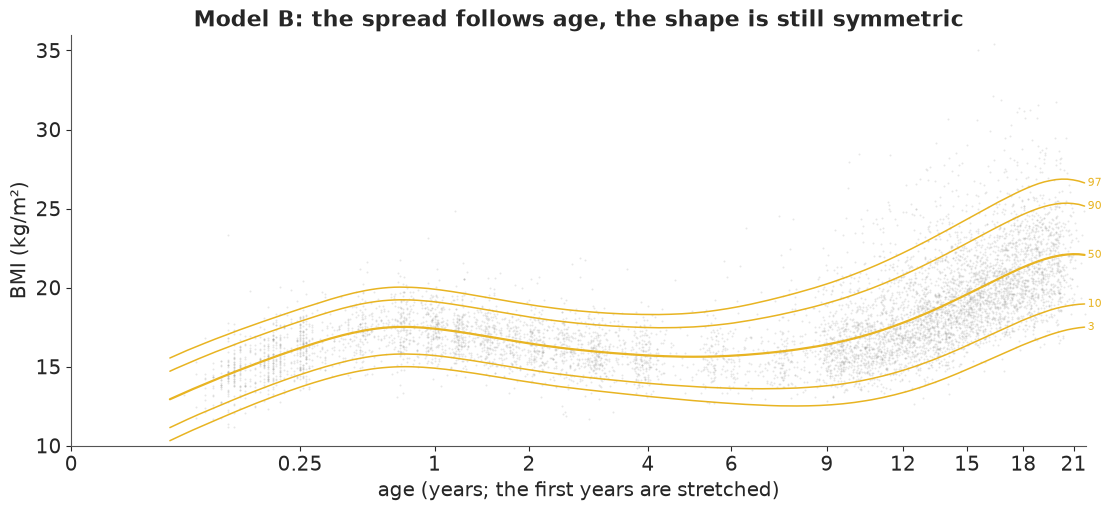

In [8]:
centiles_and_pit("B: normal, smooth spread")
fig, ax = plt.subplots(figsize=(11, 5))
centile_plot(ax, "B: normal, smooth spread", C_HET, "Model B: the spread follows age, the shape is still symmetric")
coverage_table(["A: normal, constant sd", "B: normal, smooth spread"])

# Better: the babies now get their 3% below and above. But at school age and later the
# symmetric normal fails in a new way, visible in the table: **too few boys below the 3rd line
# (0.2-0.8%) and too many above the 97th (about 5%)**. A normal distribution with the right
# spread puts its 3rd centile too low and its 97th too low, because the real distribution is
# skewed: its light side is short and its heavy side long.
#
# A note on how these curves are sampled. The random-walk wiggles can be written *centred*
# ($z \sim N(0, \tau)$) or *non-centred* ($z = \tau \tilde z$, $\tilde z \sim N(0, 1)$). The
# non-centred form is the usual advice for hierarchical models with weak data, but here each
# curve is pinned down by thousands of boys, which is the strong-data case where centring
# wins. The next cell refits model B non-centred, with the same sampler settings.

In [9]:
with pm.Model(coords=COORDS) as m_het_nc:
    f_mu = smooth("mu", *PRIORS["mu"], centred=False)
    f_sig = smooth("sig", *PRIORS["sig"], centred=False)
    pm.Normal("bmi", mu=pt.exp(f_mu), sigma=pt.exp(f_mu + f_sig), observed=BMI)
fit(m_het_nc, "B, non-centred", keep=False).loc[["mu_tau", "sig_tau"]]

B, non-centred: 15 s, 102 divergences, max r_hat 1.016, min bulk ESS 299, mean tree depth 3.8, tuning steps 800


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_tau,0.066,0.015,0.046,0.092,299.376,283.485,1.008,0.001,0.001
sig_tau,0.128,0.052,0.068,0.223,353.923,500.374,1.016,0.003,0.004


The non-centred fit has about a hundred divergences and a few hundred effective draws for the
smoothing sds, against none and about a thousand or more for the centred fit above. (In prototyping, the
non-centred LMS model with the default diagonal mass matrix took four minutes, with tree depth
7 and divergences; centred plus low-rank takes about 20 seconds.) All fits below are centred.

## 5 · Model C: the LMS / Box-Cox-Cole-Green distribution, written by hand

Cole & Green's idea: for each age there is a power $L$ such that $(y/M)^L$ is close to normal.
Write the standardised value (the **z-score** a growth chart reports)
$$z = \frac{(y/M)^{L} - 1}{L\,S} \quad (L \ne 0), \qquad z = \frac{\log(y/M)}{S} \quad (L = 0).$$
$M$ is the median, $S$ is roughly the coefficient of variation, $L = 1$ means symmetric,
$L < 1$ right-skewed ($L = 0$ is log-normal). Since $z$ must satisfy $1 + L S z > 0$, it
cannot be exactly normal: the **BCCG distribution** (the GAMLSS name) takes $z$ as a standard
normal *truncated* at $\pm 1/(S|L|)$, which gives the log-density
$$\log f(y) = L\log\frac{y}{M} - \log y - \log S + \log\varphi(z) - \log\Phi\!\left(\frac{1}{S|L|}\right),$$
and the centiles in closed form, $y_q = M(1 + L S z_q)^{1/L}$ with $z_q = \Phi^{-1}(q\,\Phi(b))$
for $L < 0$ and $\Phi^{-1}(1 - (1-q)\Phi(b))$ for $L > 0$, $b = 1/(S|L|)$.

Two implementation details matter for gradients. (1) At $L \to 0$ we use
`expm1(L log(y/M)) / L` with $L$ nudged away from exactly 0 by a switch on the *input*, so
neither branch is ever NaN. (2) PyMC's `normal_lcdf` evaluates both branches of a switch, and
its left-tail branch overflows for arguments above ~37 - reached here whenever $|L|$ is small -
so the NaN gradient leaks through (in prototyping this showed up as divergences). Because
$b > 0$ always, $\log\Phi(b) = \log(1 - \tfrac12\mathrm{erfc}(b/\sqrt2))$ is stable and
branch-free.

Before sampling, the checks from E32: the density integrates to one, the area below the
closed-form 90th centile is 0.9, it reduces to known distributions ($L = 1$: a normal
truncated at zero, `scipy.stats.truncnorm`; $L = 0$: log-normal - the small difference there
is the $10^{-6}$ nudge), and it matches a simulator of the generative story.

In [10]:
def bccg_logp(y, mu, sigma, nu):
    """log density of the Box-Cox Cole-Green distribution (median mu, spread sigma, Box-Cox power nu)."""
    nu_s = pt.switch(pt.abs(nu) < 1e-6, 1e-6, nu)       # switch on the INPUT: both branches finite
    l = pt.log(y / mu)
    z = pt.expm1(nu_s * l) / (nu_s * sigma)
    b = 1.0 / (sigma * pt.abs(nu_s))                     # truncation point of z (b > 0)
    log_phi_b = pt.log1p(-0.5 * pt.erfc(b / np.sqrt(2.0)))  # log Phi(b), stable for large b
    return nu_s * l - pt.log(y) - pt.log(sigma) - 0.5 * np.log(2 * np.pi) - 0.5 * z**2 - log_phi_b


yv, muv, sv, nv = pt.dvector("y"), pt.dscalar("mu"), pt.dscalar("s"), pt.dscalar("nu")
bccg_logp_fn = pm.compile([yv, muv, sv, nv], bccg_logp(yv, muv, sv, nv))
ygrid = np.linspace(0.5, 60, 7)
checks = []
for mu_, s_, nu_ in [(17.0, 0.1, -1.0), (17.0, 0.4, -1.5), (15.0, 0.6, 1.0), (15.0, 0.3, 0.0), (20.0, 0.2, 2.5)]:
    total = integrate.quad(lambda v: np.exp(bccg_logp_fn(np.array([v]), mu_, s_, nu_))[0], 0, np.inf, limit=200)[0]
    q90 = ppf("C", 0.9, {"mu": mu_, "sigma": s_, "nu": nu_})
    area90 = integrate.quad(lambda v: np.exp(bccg_logp_fn(np.array([v]), mu_, s_, nu_))[0], 0, q90, limit=200)[0]
    ref = {1.0: stats.truncnorm.logpdf(ygrid, -1 / s_, np.inf, loc=mu_, scale=mu_ * s_),
           0.0: stats.lognorm.logpdf(ygrid, s_, scale=mu_)}.get(nu_)
    diff = np.nan if ref is None else np.max(np.abs(bccg_logp_fn(ygrid, mu_, s_, nu_) - ref))
    checks.append({"mu": mu_, "sigma": s_, "nu": nu_, "P(truncated)": 1 - ndtr(1 / (s_ * abs(nu_ or 1e-9))),
                   "integral": total, "area below 90th centile": area90, "max |logp - scipy|": diff})
pd.DataFrame(checks).round(6)

# The integrals are 1 and 0.9 to six decimals (they print as 1.0 and 0.9), including the cases
# where 2-5% of the untruncated normal is cut off, and the special cases agree with scipy. Now
# the story: draw a truncated normal $z$, transform it to $y$, and compare the 20,000 draws
# with our CDF by a Kolmogorov-Smirnov test.

,mu,sigma,nu,P(truncated),integral,area below 90th centile,max |logp - scipy|
0,17.0,0.1,-1.0,0.00000,1.0,0.9,NaN
1,17.0,0.4,-1.5,0.04779,1.0,0.9,NaN
2,15.0,0.6,1.0,0.04779,1.0,0.9,0.000000
3,15.0,0.3,0.0,0.00000,1.0,0.9,0.000215
4,20.0,0.2,2.5,0.02275,1.0,0.9,NaN


In [11]:
# The story behind the density: z ~ Normal truncated to 1 + sigma*nu*z > 0, y = mu (1 + sigma nu z)^(1/nu).
sim_rows = []
for mu_, s_, nu_ in [(17.0, 0.4, -1.5), (15.0, 0.6, 1.0)]:
    b = 1 / (s_ * abs(nu_))
    lo_, hi_ = (-np.inf, b) if nu_ < 0 else (-b, np.inf)
    zs = stats.truncnorm.rvs(lo_, hi_, size=20000, random_state=rng)
    ys = bc_y(zs, mu_, s_, nu_)
    ks = stats.kstest(ys, lambda v: cdf("C", v, {"mu": mu_, "sigma": s_, "nu": nu_}))
    sim_rows.append({"mu": mu_, "sigma": s_, "nu": nu_, "KS statistic": ks.statistic, "KS p-value": ks.pvalue})
pd.DataFrame(sim_rows).round(3)

# Both KS statistics are below 0.01 with unremarkable p-values: the density and the simulator
# tell the same story. Now the model, with all three LMS parameters as P-splines in age.

,mu,sigma,nu,KS statistic,KS p-value
0,17.0,0.4,-1.5,0.005,0.788
1,15.0,0.6,1.0,0.008,0.168


In [12]:
with pm.Model(coords=COORDS) as m_bccg:
    f_mu = smooth("mu", *PRIORS["mu"])
    f_sig = smooth("sig", *PRIORS["sig"])
    f_nu = smooth("nu", *PRIORS["nu"])
    pm.CustomDist("bmi", pt.exp(f_mu), pt.exp(f_sig), f_nu, logp=bccg_logp, observed=BMI)
fit(m_bccg, "C: BCCG (LMS)")

C: BCCG (LMS): 22 s, 0 divergences, max r_hat 1.005, min bulk ESS 513, mean tree depth 3.3, tuning steps 800


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_a,2.759,0.021,2.725,2.793,3817.569,2795.594,1.000,0.000,0.000
mu_b,0.202,0.033,0.151,0.254,3884.046,2727.750,1.000,0.001,0.001
sig_a,-2.318,0.049,-2.388,-2.236,2905.049,1698.718,1.001,0.001,0.001
sig_b,0.023,0.073,-0.100,0.126,2729.696,1513.563,1.002,0.002,0.002
nu_a,-1.023,0.280,-1.468,-0.566,4528.935,3005.031,1.002,0.004,0.005
nu_b,-0.178,0.408,-0.821,0.476,4986.493,2714.300,1.001,0.006,0.008
mu_tau,0.070,0.017,0.047,0.101,3188.394,2748.333,1.001,0.000,0.000
sig_tau,0.106,0.055,0.048,0.199,512.616,664.695,1.005,0.003,0.005
nu_tau,0.600,0.226,0.300,1.009,721.055,1090.584,1.004,0.008,0.005


### The classic, non-Bayesian way: LMS estimated age band by age band

Before smooth-curve software, LMS curves were made by estimating $L, M, S$ by maximum
likelihood in narrow age groups and then smoothing the three sequences by eye or by spline.
We do the first step with SciPy (24 age bins of about 300 boys each, with bootstrap standard
errors) as a frequentist reference point for the Bayesian curves.

In [13]:
def bccg_negll(theta, y):
    mu_, s_, nu_ = np.exp(theta[0]), np.exp(theta[1]), theta[2]
    return -logpdf("C", y, {"mu": mu_, "sigma": s_, "nu": nu_}).sum()


def lms_ml(y):
    th0 = [np.log(np.median(y)), np.log(np.std(np.log(y))), 0.0]
    return optimize.minimize(bccg_negll, th0, args=(y,), method="Nelder-Mead",
                             options={"xatol": 1e-5, "fatol": 1e-6, "maxiter": 4000}).x


N_BINS, N_BOOT = 24, 30
bin_id = pd.qcut(AGE, N_BINS, labels=False)
binned = []
for j in range(N_BINS):
    yj = BMI[bin_id == j]
    est = lms_ml(yj)
    boot = np.array([lms_ml(rng.choice(yj, len(yj))) for _ in range(N_BOOT)])
    binned.append({"age": np.median(AGE[bin_id == j]), "n": len(yj),
                   "M": np.exp(est[0]), "S": np.exp(est[1]), "L": est[2],
                   "M_se": np.exp(boot[:, 0]).std(), "S_se": np.exp(boot[:, 1]).std(), "L_se": boot[:, 2].std()})
binned = pd.DataFrame(binned)
binned.round(3).head(8)

# The binned maximum-likelihood estimates of $L$ jump around by one or two units from bin to
# bin, with bootstrap standard errors of 0.5-1: the skewness of 300 boys is hard to estimate.
# This is exactly why the curves are smoothed.

,age,n,M,S,L,M_se,S_se,L_se
0,0.11,348,14.814,0.094,-0.104,0.075,0.005,0.662
1,0.25,269,16.040,0.082,-0.375,0.111,0.003,0.701
2,0.50,298,17.120,0.074,-0.170,0.062,0.003,0.658
3,0.84,307,17.475,0.081,0.585,0.071,0.004,0.768
4,1.20,299,17.085,0.075,-1.491,0.063,0.004,0.925
5,1.58,303,16.710,0.073,-0.262,0.080,0.003,0.488
6,2.17,306,16.385,0.082,1.184,0.064,0.004,0.666
7,2.96,302,15.847,0.081,-1.254,0.081,0.004,1.041


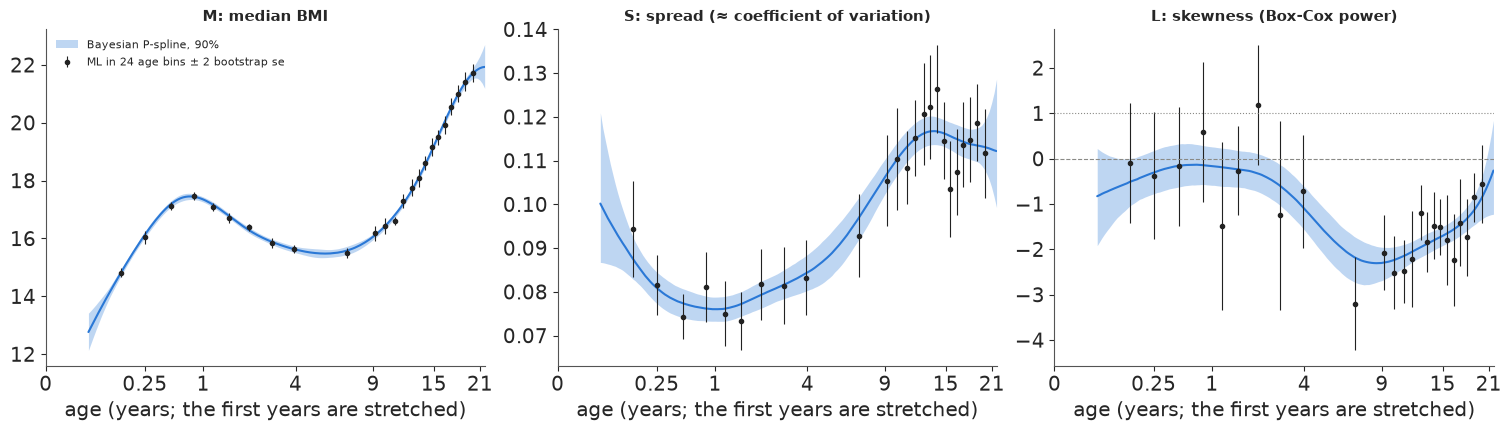

In [14]:
centiles_and_pit("C: BCCG (LMS)")
pC = model_draws("C: BCCG (LMS)", FITS["C: BCCG (LMS)"], B_GRID)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (k, lab, col) in zip(axes, [("mu", "M: median BMI", "M"), ("sigma", "S: spread (≈ coefficient of variation)", "S"),
                                    ("nu", "L: skewness (Box-Cox power)", "L")]):
    v = pC[k]
    ax.fill_between(AGE_GRID, *np.quantile(v, [0.05, 0.95], axis=0), color=C_BCCG, alpha=0.3, lw=0,
                    label="Bayesian P-spline, 90%")
    ax.plot(AGE_GRID, np.median(v, axis=0), color=C_BCCG)
    ax.errorbar(binned.age, binned[col], 2 * binned[f"{col}_se"], fmt="o", ms=3, color=INK, lw=0.8,
                label=f"ML in {N_BINS} age bins ± 2 bootstrap se")
    age_axis(ax, ticks=[0, 0.25, 1, 4, 9, 15, 21])
    ax.set_title(lab, fontsize=11)
axes[2].axhline(1, color=GREY, lw=0.8, ls=":")
axes[2].axhline(0, color=GREY, lw=0.8, ls="--")
axes[0].legend(fontsize=8, loc="upper left");

# The three LMS curves, with the binned ML estimates on top. The Bayesian median and spread
# curves go through the binned estimates; the skewness curve does too, with a band much narrower
# than any single bin's error bar, because it borrows strength across ages. The story the
# curves tell: BMI is **most variable in puberty** (S rises from under 8% at age 1 to about 12%
# at 12-15) and **most skewed at school age** (L falls from about 0 in infancy - roughly
# log-normal - to about -2 around ages 7-10, and moves back towards 0 by age 21). The band on L
# is widest for the youngest babies, at ages 4-9 where few boys were measured, and at 21, the
# edge of the data.

B: normal, smooth spread              C: BCCG (LMS)             
                      % below 3rd % above 97th   % below 3rd % above 97th
0-6 mo                        2.4          3.3           3.6          2.3
6 mo-2 y                      1.9          3.2           2.5          3.0
2-5 y                         1.7          3.1           2.9          2.5
5-9 y                         0.7          4.9           2.7          3.1
9-13 y                        0.2          4.9           2.8          3.2
13-17 y                       0.4          4.9           2.6          3.2
17-21 y                       0.7          5.1           2.7          3.7
all ages                      1.0          4.3           2.8          3.1

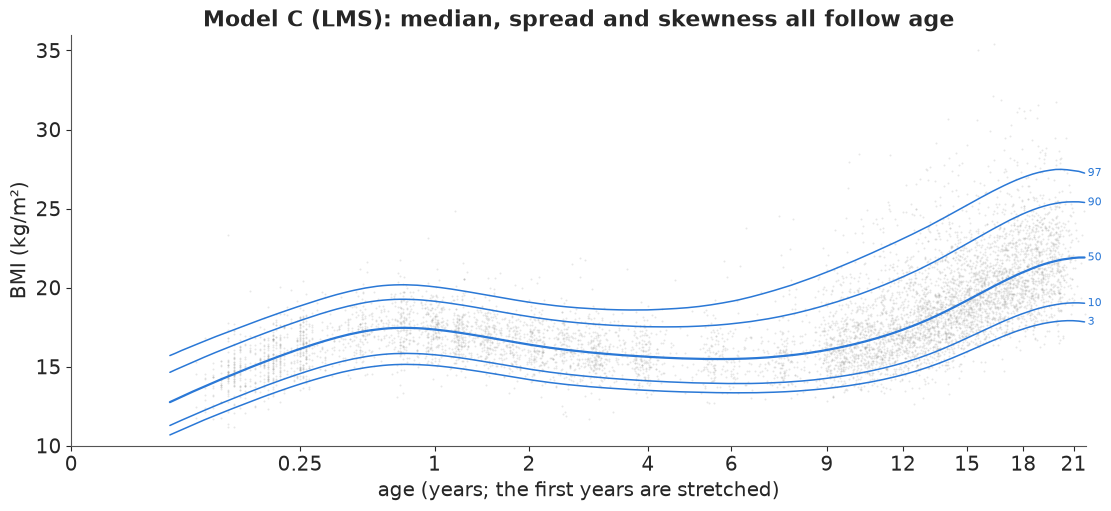

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
centile_plot(ax, "C: BCCG (LMS)", C_BCCG, "Model C (LMS): median, spread and skewness all follow age")
coverage_table(["B: normal, smooth spread", "C: BCCG (LMS)"])

Now the centile lines fan out upward at school age and after, and the coverage table is close to
3% and 3% in every age band (2.5-3.7%, against 0.2-5.1% for model B).

> **In plain words:** a child's BMI is not spread evenly around the average. From school age
> on, some boys are far heavier than average and almost none are far lighter. Once the chart
> is allowed to be lopsided, "3 in 100" means 3 in 100 at every age.

## 6 · Model D: a fourth parameter for the tails (Box-Cox t)

GAMLSS adds a fourth parameter for kurtosis: the **Box-Cox t** (BCT; Rigby & Stasinopoulos
2006) replaces the normal for $z$ by a Student t with $\tau$ degrees of freedom. Writing it
exactly again needs a truncation term, now a t CDF with free $\tau$, i.e. an incomplete beta
function whose gradient costs a lot: in prototyping the exact BCT took 3-4 minutes and one
chain got stuck. Here the truncated mass is tiny (checked below), so we use the untruncated
density (as the `BCTuntr` family in `gamlss` does), with one $\tau$ for all ages - a smooth
$\tau(t)$ took four times as long and gave divergences in prototyping. The checks against
scipy are the log-t for $L = 0$ and the Jacobian identity for any $L$.

In [16]:
def bct_logp(y, mu, sigma, nu, tau):
    """Box-Cox t (untruncated form): z = Box-Cox transform of y/mu, z ~ Student-t with tau d.o.f."""
    nu_s = pt.switch(pt.abs(nu) < 1e-6, 1e-6, nu)
    l = pt.log(y / mu)
    z = pt.expm1(nu_s * l) / (nu_s * sigma)
    log_t = (pt.gammaln((tau + 1) / 2) - pt.gammaln(tau / 2) - 0.5 * pt.log(np.pi * tau)
             - (tau + 1) / 2 * pt.log1p(z**2 / tau))
    return nu_s * l - pt.log(y) - pt.log(sigma) + log_t


tv = pt.dscalar("tau")
bct_fn = pm.compile([yv, muv, sv, nv, tv], bct_logp(yv, muv, sv, nv, tv))
print("BCT check against scipy (nu = 0: log-t; any nu: Jacobian + t density):",
      np.max(np.abs(bct_fn(ygrid, 15.0, 0.2, 0.0, 6.0)
                    - (stats.t.logpdf(np.log(ygrid / 15) / 0.2, 6) - np.log(ygrid * 0.2)))),
      np.max(np.abs(bct_fn(ygrid, 17.0, 0.12, -1.2, 8.0)
                    - logpdf("D", ygrid, {"mu": 17.0, "sigma": 0.12, "nu": -1.2, "tau": 8.0}))))

with pm.Model(coords=COORDS) as m_bct:
    f_mu = smooth("mu", *PRIORS["mu"])
    f_sig = smooth("sig", *PRIORS["sig"])
    f_nu = smooth("nu", *PRIORS["nu"])
    log_tau = pm.Normal("log_tau", np.log(10.0), 1.0)
    pm.CustomDist("bmi", pt.exp(f_mu), pt.exp(f_sig), f_nu, pt.exp(log_tau), logp=bct_logp, observed=BMI)
fit(m_bct, "D: BCT (LMS + tails)")

# No divergences, r_hat at most 1.01, about 20 seconds.

BCT check against scipy (nu = 0: log-t; any nu: Jacobian + t density): 8.261037590884257e-06 1.7763568394002505e-15


D: BCT (LMS + tails): 19 s, 0 divergences, max r_hat 1.008, min bulk ESS 750, mean tree depth 3.3, tuning steps 800


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_a,2.760,0.021,2.726,2.792,3907.257,2981.482,1.001,0.000,0.000
mu_b,0.202,0.032,0.151,0.254,3919.432,3083.058,1.001,0.001,0.001
sig_a,-2.391,0.045,-2.459,-2.315,4133.207,2310.652,1.006,0.001,0.001
sig_b,0.051,0.066,-0.061,0.146,3757.724,2155.194,1.007,0.001,0.001
nu_a,-0.841,0.293,-1.312,-0.369,4695.021,2759.870,1.001,0.004,0.005
nu_b,-0.398,0.422,-1.063,0.294,4479.366,2506.801,1.002,0.006,0.008
log_tau,2.928,0.183,2.658,3.239,3490.766,2260.979,1.000,0.003,0.003
mu_tau,0.070,0.018,0.048,0.102,2838.012,2453.647,1.001,0.000,0.000
sig_tau,0.090,0.041,0.044,0.167,755.875,908.467,1.008,0.002,0.002
nu_tau,0.494,0.189,0.250,0.851,749.718,1121.391,1.002,0.007,0.004


In [17]:
centiles_and_pit("D: BCT (LMS + tails)")
pD = model_draws("D: BCT (LMS + tails)", FITS["D: BCT (LMS + tails)"], B_GRID, n=1000)
b_trunc = 1 / (pD["sigma"] * np.abs(pD["nu"]))
missing = stats.t.sf(b_trunc, pD["tau"])
tau_draws = np.exp(stacked(FITS["D: BCT (LMS + tails)"].posterior["log_tau"]))
print(f"tail degrees of freedom tau: median {np.median(tau_draws):.0f}, 90% {np.quantile(tau_draws, 0.05):.0f}-"
      f"{np.quantile(tau_draws, 0.95):.0f}; untruncated-density mass lost: max over ages and draws {missing.max():.1e}")
pC1 = model_draws("C: BCCG (LMS)", FITS["C: BCCG (LMS)"], B_GRID, n=1000)
for a_ in [4, 12, 16, 21]:
    j = np.argmin(np.abs(AGE_GRID - a_))
    print(f"age {a_:>2}: 3rd / 97th / 99.6th centile  C {[round(float(np.median(ppf('C', q, {k: v[:, j] for k, v in pC1.items()}))), 2) for q in (0.03, 0.97, 0.996)]}"
          f"  D {[round(float(np.median(ppf('D', q, {k: v[:, j] for k, v in pD.items()}))), 2) for q in (0.03, 0.97, 0.996)]}")
coverage_table(["C: BCCG (LMS)", "D: BCT (LMS + tails)"])

tail degrees of freedom tau: median 19, 90% 14-26; untruncated-density mass lost: max over ages and draws 1.8e-03
age  4: 3rd / 97th / 99.6th centile  C [13.5, 18.59, 20.19]  D [13.5, 18.62, 20.57]
age 12: 3rd / 97th / 99.6th centile  C [14.45, 23.02, 27.9]  D [14.43, 23.07, 29.3]
age 16: 3rd / 97th / 99.6th centile  C [16.49, 25.9, 30.19]  D [16.45, 25.97, 31.32]
age 21: 3rd / 97th / 99.6th centile  C [17.91, 27.4, 30.34]  D [17.87, 27.53, 31.11]


C: BCCG (LMS)              D: BCT (LMS + tails)             
           % below 3rd % above 97th          % below 3rd % above 97th
0-6 mo             3.6          2.3                  3.2          2.5
6 mo-2 y           2.5          3.0                  2.4          3.0
2-5 y              2.9          2.5                  2.9          2.5
5-9 y              2.7          3.1                  2.4          3.1
9-13 y             2.8          3.2                  2.8          3.2
13-17 y            2.6          3.2                  2.5          2.9
17-21 y            2.7          3.7                  2.4          3.6
all ages           2.8          3.1                  2.6          3.0

The tails need about 19 degrees of freedom (90%: 14-26): moderately heavier than normal. The
density mass lost by not truncating is at most 0.2% for any age and draw, small enough to
ignore. At the 3rd and 97th centiles C and D agree to within 0.1 BMI units; they differ only
further out: the 99.6th centile (about $z = +2.65$, the top line of the UK nine-centile
charts) is about 0.8-1.4 units higher under the heavier-tailed model at ages 12-21.

## 7 · Checking the fit: worm plots and LOO

A **worm plot** (van Buuren & Fredriks 2001, *Statistics in Medicine*) is the growth-chart
diagnostic: within an age band, turn each boy's BMI into a z-score with the model
($\Phi^{-1}$ of the posterior-averaged CDF), make a normal Q-Q plot and subtract the diagonal.
A good model gives a flat worm inside the grey 95% band; a worm with a slope means the wrong
spread, a U or an inverted U the wrong skewness, an S-shape the wrong tails.

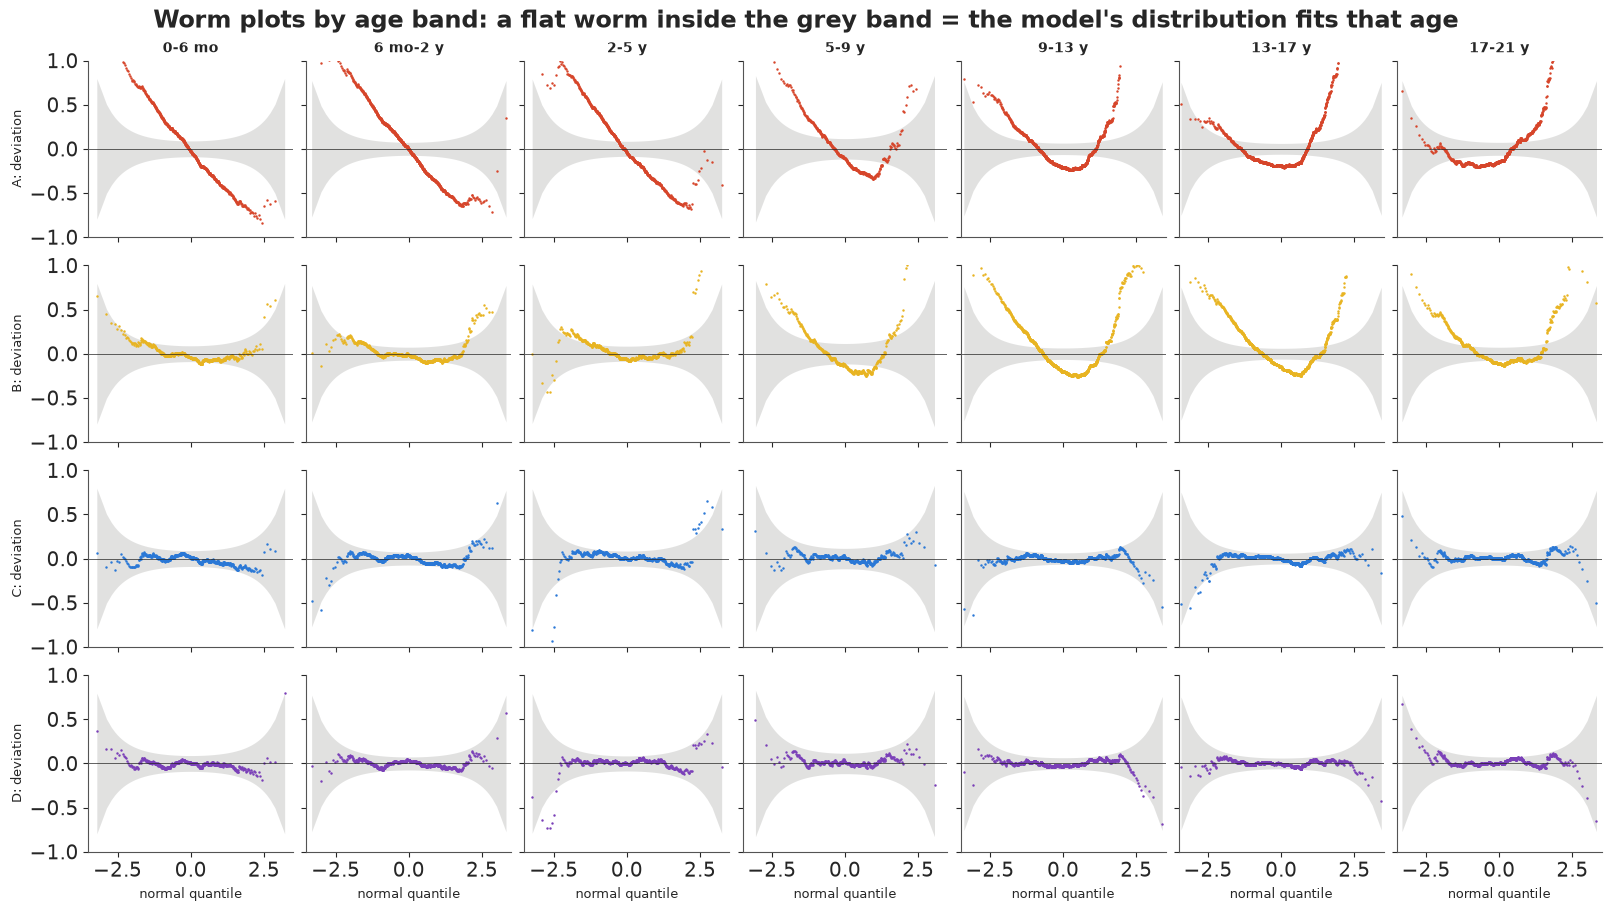

In [18]:
KEYS = list(FITS)
COLORS = dict(zip(KEYS, [C_NORM, C_HET, C_BCCG, C_BCT]))
fig, axes = plt.subplots(len(KEYS), len(BAND_LABELS), figsize=(16, 9), sharex=True, sharey=True)
for r, key in enumerate(KEYS):
    res = ndtri(np.clip(PIT[key], 1e-6, 1 - 1e-6))
    for c, lab in enumerate(BAND_LABELS):
        ax = axes[r, c]
        rj = np.sort(res[band.to_numpy() == lab])
        n = len(rj)
        pp = (np.arange(1, n + 1) - 0.5) / n
        qn = ndtri(pp)
        band_se = 1.96 * np.sqrt(pp * (1 - pp) / n) / stats.norm.pdf(qn)
        ax.fill_between(qn, -band_se, band_se, color=GREY, alpha=0.25, lw=0)
        ax.plot(qn, rj - qn, ".", ms=1.5, color=COLORS[key])
        ax.axhline(0, color=INK, lw=0.5)
        ax.set(xlim=(-3.5, 3.5), ylim=(-1.0, 1.0))
        if r == 0:
            ax.set_title(lab, fontsize=10)
        if c == 0:
            ax.set_ylabel(key.split(":")[0] + ": deviation", fontsize=9)
        if r == len(KEYS) - 1:
            ax.set_xlabel("normal quantile", fontsize=9)
fig.suptitle("Worm plots by age band: a flat worm inside the grey band = the model's distribution fits that age");

# Reading the worms: model A's worms are steep lines at young ages (the spread is far too big)
# and U-shapes later (wrong spread plus wrong skewness). Model B fixes the slopes but keeps a
# U-shape from age 5 on - the missing skewness. Models C and D are flat, except for a handful of
# points in the extreme tails; at 13-17 C's worm leaves the band at its low end (the lightest
# boys), D's does not. The table counts the share of each worm outside its band.

In [19]:
def worm_stats(key):
    res = ndtri(np.clip(PIT[key], 1e-6, 1 - 1e-6))
    out = {}
    for lab in BAND_LABELS:
        rj = np.sort(res[band.to_numpy() == lab])
        n = len(rj)
        pp = (np.arange(1, n + 1) - 0.5) / n
        qn = ndtri(pp)
        se = 1.96 * np.sqrt(pp * (1 - pp) / n) / stats.norm.pdf(qn)
        out[lab] = np.mean(np.abs(rj - qn) > se) * 100
    return out


pd.DataFrame({k: worm_stats(k) for k in KEYS}).T.round(1).rename_axis("% of worm outside the band")

# PSIS-LOO on 1,000 of the 4,000 draws (thinned to keep the 7,294-column log-likelihood small):

,0-6 mo,6 mo-2 y,2-5 y,5-9 y,9-13 y,13-17 y,17-21 y
% of worm outside the band,,,,,,,
"A: normal, constant sd",84.1,84.8,84.4,67.3,81.6,87.0,81.3
"B: normal, smooth spread",6.4,18.7,10.5,62.7,84.1,74.6,54.4
C: BCCG (LMS),0.1,0.5,1.9,0.0,0.1,3.7,0.0
D: BCT (LMS + tails),0.1,0.0,0.7,0.0,0.1,0.1,0.0


In [20]:
LOO = {}
for key, model in zip(KEYS, [m_norm, m_het, m_bccg, m_bct]):
    th = FITS[key].isel(draw=slice(None, None, 4))
    pm.compute_log_likelihood(th, model=model, progressbar=False)
    LOO[key] = az.loo(th, pointwise=True)
    LOO[key].log_weights = None
    del th
    print(f"{key}: elpd {LOO[key].elpd:.0f} (se {LOO[key].se:.0f}), p_loo {LOO[key].p:.1f}, "
          f"Pareto k > 0.7: {int((LOO[key].pareto_k > 0.7).sum())}")
cmp = az.compare(LOO, round_to=1)
cmp

A: normal, constant sd: elpd -15646 (se 102), p_loo 12.3, Pareto k > 0.7: 0


B: normal, smooth spread: elpd -15084 (se 92), p_loo 28.6, Pareto k > 0.7: 0


C: BCCG (LMS): elpd -14620 (se 77), p_loo 30.4, Pareto k > 0.7: 0


D: BCT (LMS + tails): elpd -14602 (se 76), p_loo 25.6, Pareto k > 0.7: 0


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
D: BCT (LMS + tails),0,0.0,0.0,NaN,,,25.6,-14602.1,75.8,0.9
C: BCCG (LMS),1,-17.6,7.3,1.0,,,30.4,-14619.7,76.8,0.1
"B: normal, smooth spread",2,-482.3,40.4,1.0,,,28.6,-15084.4,92.2,0.0
"A: normal, constant sd",3,-1043.8,61.4,1.0,,,12.3,-15646.0,102.0,0.0


The ranking agrees with the worm plots. Skewness is worth about 460 points of elpd over model B
(a difference of more than ten standard errors), a smooth spread about 560 points over A, and
the tails about 18 more for D over C (dse about 7, so about 2.4 standard errors: real but
modest). No Pareto k is above 0.7 for C and D. We use **model D** from here on. (A
frequentist GAMLSS fit of the same model would give essentially the same curves; the binned
ML estimates above already show the agreement at the level of the LMS parameters.)

> **In plain words:** four checks - the share of boys outside the lines, the worm plots, a
> cross-validation score and the classic age-bin estimates - all say the same thing: the chart
> needs to follow the average, the spread and the lopsidedness at each age, and a little extra
> room in the tails helps.

## 8 · Where are the centile lines uncertain?

A growth chart is normally printed as sharp lines. Each line is an estimate, and the
posterior gives every line its own uncertainty: we take the 4,000 draws of the four curves and
compute the centile lines for each.

  3rd centile: 90% width median over ages 0.27, largest 1.50 at age 21.7
 10th centile: 90% width median over ages 0.22, largest 1.36 at age 21.7
 50th centile: 90% width median over ages 0.21, largest 1.49 at age 21.7
 90th centile: 90% width median over ages 0.36, largest 2.04 at age 21.7
 97th centile: 90% width median over ages 0.64, largest 2.88 at age 21.7
age  0.1: 97th centile 17.37 (90% 17.12-17.66); 50th 14.69
age    1: 97th centile 20.05 (90% 19.89-20.21); 50th 17.35
age    4: 97th centile 18.62 (90% 18.36-18.89); 50th 15.62
age    7: 97th centile 19.70 (90% 19.31-20.18); 50th 15.58
age   12: 97th centile 23.07 (90% 22.73-23.49); 50th 17.29
age   16: 97th centile 25.97 (90% 25.64-26.35); 50th 19.85
age   21: 97th centile 27.53 (90% 26.67-28.59); 50th 21.89


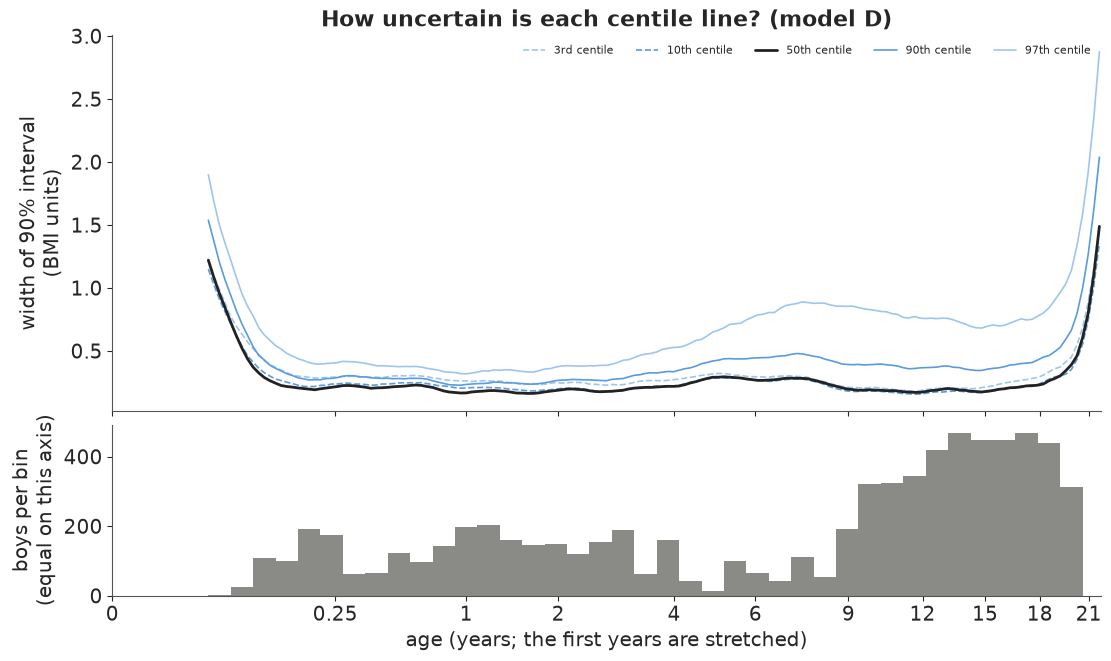

In [21]:
BEST = "D: BCT (LMS + tails)"
CB = CENT[BEST]
width = np.quantile(CB, 0.95, axis=1) - np.quantile(CB, 0.05, axis=1)     # (centile, age)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2.2, 1])
ax = axes[0]
for i, q in enumerate(CENTILES):
    ax.plot(AGE_GRID, width[i], color=C_RAMP[i] if q != 0.5 else INK, lw=1.2 if q != 0.5 else 2,
            ls="-" if q >= 0.5 else "--", label=f"{ordinal(q)} centile")
ax.set(ylabel="width of 90% interval\n(BMI units)", title="How uncertain is each centile line? (model D)")
ax.legend(fontsize=8, ncol=5)
ax = axes[1]
ax.hist(AGE, bins=AGE_GRID[::4], color=GREY)
ax.set_ylabel("boys per bin\n(equal on this axis)")
age_axis(ax)
for i, q in enumerate(CENTILES):
    j = np.argmax(width[i])
    print(f"{ordinal(q):>5} centile: 90% width median over ages {np.median(width[i]):.2f}, "
          f"largest {width[i, j]:.2f} at age {AGE_GRID[j]:.1f}")
for a_ in [0.1, 1, 4, 7, 12, 16, 21]:
    j = np.argmin(np.abs(AGE_GRID - a_))
    print(f"age {a_:>4}: 97th centile {np.median(CB[4, :, j]):.2f} (90% {np.quantile(CB[4, :, j], 0.05):.2f}-"
          f"{np.quantile(CB[4, :, j], 0.95):.2f}); 50th {np.median(CB[2, :, j]):.2f}")

Three honest points:

- **The extreme centiles are the uncertain ones.** At a typical age the 90% interval of the
  97th centile is about 0.6 BMI units wide, three times the median's 0.2. The 3rd centile is
  much better determined than the 97th (0.3), because the distribution's light side is
  short and its heavy side long and sparse.
- **Uncertainty follows the data.** The 97th-centile width grows from about 0.35 at age 1-2
  to nearly 0.9 around age 7, where the survey measured few boys, even though BMI changes
  slowly there. The printed chart looks equally confident everywhere; it is not.
- **The ends are the worst.** At 21 years (the edge of the data: the curve has nothing on its
  right) all lines widen sharply, the 97th to almost 3 units; at the first weeks of life the
  same happens on the left.

> **In plain words:** the lines on a growth chart are themselves estimates. The middle line
> is known very precisely at almost every age; the top line is less certain, especially for
> school-age boys and young men, where fewer were measured or the heavy tail is long.

## 9 · Explaining it to everyone

The displays below are for a parent, a school nurse or a journalist. Every number in them is
computed from model D's posterior above. The example boys are **hypothetical**: we chose a BMI
near the 95th centile for a 7-year-old and a 15-year-old to show how the chart is read.

**What a centile does NOT mean.** "Above the 95th centile" means that about 5 in 100 Dutch
boys of that age measured in 1996-7 had a higher BMI. It is a description of a *reference
population*, not a diagnosis: it does not say that the boy is unhealthy, that his BMI is too
high, or what it will be next year (the data follow no boy over time). BMI does not tell fat
from muscle, and a reference from the Netherlands in the 1990s is not a *standard* of how
children should grow (the WHO standards try to be that). A doctor uses the centile as one
clue, along with how a child's own curve has moved over several visits.

### 9.1 A growth chart whose lines are honest about themselves

A printed chart draws each centile as a crisp line. Here each line is a blur: the darkest core
holds the line in 3 of 10 plausible versions of the chart, the middle shade in 6 of 10, the
palest edge in 9 of 10. The labels say what each line means in words.

97th centile at age 7: 19.7 (likely 19.3-20.2); at age 15: 25.4


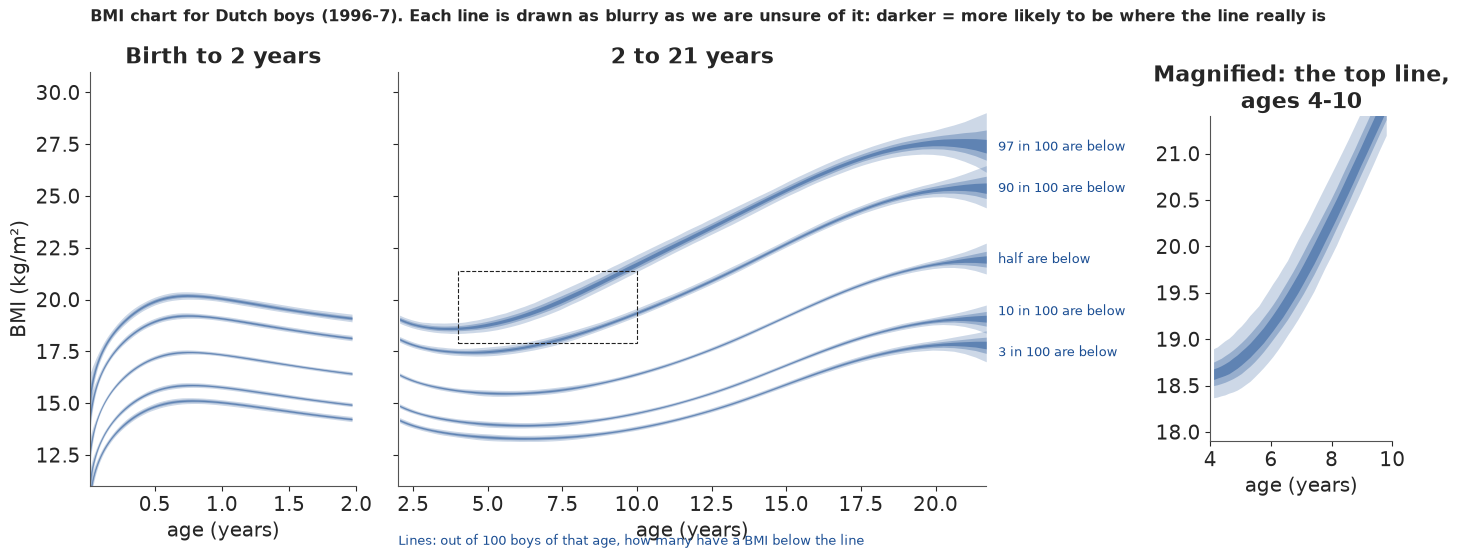

In [22]:
BLUE_DARK = "#1c4f94"
LEVELS = [(0.05, 0.95, 0.22), (0.2, 0.8, 0.3), (0.35, 0.65, 0.45)]
WORDS = {0.03: "3 in 100 are below", 0.10: "10 in 100 are below",
         0.50: "half are below", 0.90: "90 in 100 are below", 0.97: "97 in 100 are below"}
HOVER = {0.03: "3 in 100 boys", 0.10: "10 in 100 boys", 0.50: "half of all boys", 0.90: "90 in 100 boys",
         0.97: "97 in 100 boys"}


def blurred(ax, lo, hi, which=range(len(CENTILES)), labels=True):
    m = (AGE_GRID >= lo) & (AGE_GRID <= hi)
    for i in which:
        Q = CB[i][:, m]
        for qlo, qhi, al in LEVELS:
            ax.fill_between(AGE_GRID[m], np.quantile(Q, qlo, axis=0), np.quantile(Q, qhi, axis=0),
                            color=BLUE_DARK, alpha=al, lw=0)
        if labels:
            dy = {0.03: -0.35, 0.10: 0.35}.get(CENTILES[i], 0.0)
            ax.text(AGE_GRID[m][-1] + 0.02 * (hi - lo), np.median(Q[:, -1]) + dy, WORDS[CENTILES[i]], fontsize=9,
                    va="center", color=BLUE_DARK)
    ax.set_xlim(lo, hi)


fig = plt.figure(figsize=(14, 5.6), layout="none")
ax1 = fig.add_axes([0.05, 0.12, 0.19, 0.74])
ax2 = fig.add_axes([0.27, 0.12, 0.42, 0.74])
ax3 = fig.add_axes([0.85, 0.2, 0.13, 0.58])
blurred(ax1, 0.02, 2.0, labels=False)
ax1.set(ylim=(11, 31), xlabel="age (years)", ylabel="BMI (kg/m²)", title="Birth to 2 years")
blurred(ax2, 2.0, 21.7)
ax2.set(ylim=(11, 31), xlabel="age (years)", title="2 to 21 years", yticklabels=[])
ax2.set_xlim(2, 21.7)
blurred(ax3, 4.0, 10.0, which=[4], labels=False)
m_ = (AGE_GRID >= 4) & (AGE_GRID <= 10)
ax3.set(xlabel="age (years)", title="Magnified: the top line,\nages 4-10", ylim=(17.9, 21.4))
ax2.add_patch(plt.Rectangle((4, 17.9), 6, 3.5, fill=False, ec=INK, lw=0.8, ls="--"))
fig.text(0.05, 0.95, "BMI chart for Dutch boys (1996-7). Each line is drawn as blurry as we are unsure of it: "
         "darker = more likely to be where the line really is", fontsize=11.5, weight="bold")
fig.text(0.27, 0.015, "Lines: out of 100 boys of that age, how many have a BMI below the line", fontsize=9.5, color=BLUE_DARK)
j7 = np.argmin(np.abs(AGE_GRID - 7))
print(f"97th centile at age 7: {np.median(CB[4, :, j7]):.1f} (likely {np.quantile(CB[4, :, j7], 0.05):.1f}-"
      f"{np.quantile(CB[4, :, j7], 0.95):.1f}); at age 15: "
      f"{np.median(CB[4, :, np.argmin(np.abs(AGE_GRID - 15))]):.1f}");

**Why it works:** it is the chart parents already know, drawn at the same size, so the only new
thing is the blur - and the blur is visibly thin for the middle line and thick for the top
line at 20 years. The magnified panel shows what a printed chart hides at ages 4-10: the top
line is a band almost a BMI unit wide (19.3-20.2 at age 7). **What it hides:** the blur
has no numbers on it, and on the full-size panels most of it is thinner than the line width,
which is itself an honest message (the chart is mostly well determined).

### 9.2 "Put your child on the chart"

A parent's question is about one child: "of 100 boys his age, how many are heavier?" Two
example boys, both near the 95th centile, as an icon array of 100 boys. Hatched boys are the
uncertainty: in some plausible versions of the chart they are heavier than our boy, in others
not.

example boy aged 7, BMI 18.9: 5.0 in 100 boys his age have a higher BMI (90%: 4.0-6.3); z-score 1.64 (1.53 to 1.76)
example boy aged 15, BMI 24.2: 4.9 in 100 boys his age have a higher BMI (90%: 4.3-5.5); z-score 1.65 (1.60 to 1.71)


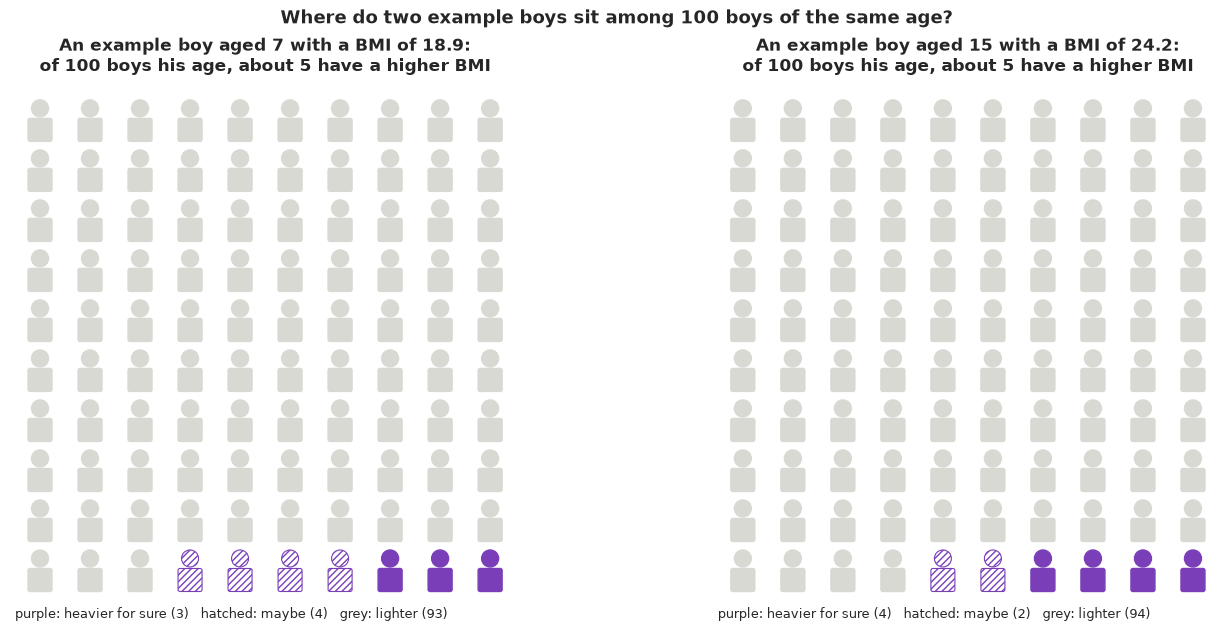

In [23]:
def params_at(age, n=None):
    p = model_draws(BEST, FITS[BEST], basis([age]), n=n)
    return {k: v[:, 0] for k, v in p.items()}


EXAMPLES = []
for age_ex in (7.0, 15.0):
    p_ex = params_at(age_ex)
    bmi_ex = round(float(np.median(ppf(BEST, 0.95, p_ex))), 1)       # an example boy near the 95th centile
    heavier = 100 * (1 - cdf(BEST, bmi_ex, p_ex))
    EXAMPLES.append({"age": age_ex, "bmi": bmi_ex, "heavier": heavier, "z": ndtri(1 - heavier / 100),
                     "q": np.quantile(heavier, [0.05, 0.5, 0.95])})
    e = EXAMPLES[-1]
    print(f"example boy aged {age_ex:g}, BMI {bmi_ex}: {e['q'][1]:.1f} in 100 boys his age have a higher BMI "
          f"(90%: {e['q'][0]:.1f}-{e['q'][2]:.1f}); z-score {np.median(e['z']):.2f} "
          f"({np.quantile(e['z'], 0.05):.2f} to {np.quantile(e['z'], 0.95):.2f})")


def boy(ax, x, y, **kw):
    ax.add_patch(Circle((x, y + 0.62), 0.17, **kw))
    ax.add_patch(FancyBboxPatch((x - 0.2, y), 0.4, 0.38, boxstyle="round,pad=0.04", **kw))


fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for ax, e in zip(axes, EXAMPLES):
    lo_n, hi_n = int(np.floor(e["q"][0])), int(np.ceil(e["q"][2]))
    for i in range(100):
        r_, c_ = divmod(i, 10)
        k = 99 - i                                   # count from the heaviest end
        if k < lo_n:
            kw = dict(color=C_BCT)
        elif k < hi_n:
            kw = dict(facecolor="white", edgecolor=C_BCT, hatch="/////", lw=0.8)
        else:
            kw = dict(color="#d9d9d4")
        boy(ax, c_, 9 - r_, **kw)
    ax.set(xlim=(-0.6, 9.6), ylim=(-0.4, 10.2), aspect="equal", xticks=[], yticks=[])
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_title(f"An example boy aged {e['age']:g} with a BMI of {e['bmi']}:\nof 100 boys his age, about "
                 f"{e['q'][1]:.0f} have a higher BMI", fontsize=12)
    ax.text(-0.5, -0.35, f"purple: heavier for sure ({lo_n})   hatched: maybe ({hi_n - lo_n})   grey: lighter ({100 - hi_n})",
            fontsize=9, va="top")
fig.suptitle("Where do two example boys sit among 100 boys of the same age?", fontsize=13, weight="bold");

**Why it works:** a frequency out of 100 is the most reliably understood format of risk
communication, and it is exactly what a centile *is*. Hatched figures turn "the 95th centile,
give or take" into something one can count: for the 7-year-old about 5 in 100 are heavier,
somewhere between 4 and 6-7, a few boys we are unsure about; for the 15-year-old the range is
narrower (about 4-6) because far more teenagers were measured. **What it hides:** the counts
are for the population of Dutch boys in 1996-7, and the hatching shows only the uncertainty of
the chart, not measurement error in the boy's own weight and height (often the larger one).

### 9.3 Twenty equally likely boys

What does "a BMI of 18.9 at age 7" look like among boys of the same age? A quantile dotplot:
20 dots are 20 equally likely boys of that age, drawn from the model's predictive
distribution (which includes the uncertainty of the chart). Orange dots have a higher BMI than
the example boy.

age 7: 20 dots from 13.3 to 20.0, median 15.6
age 15: 20 dots from 15.9 to 25.8, median 19.2


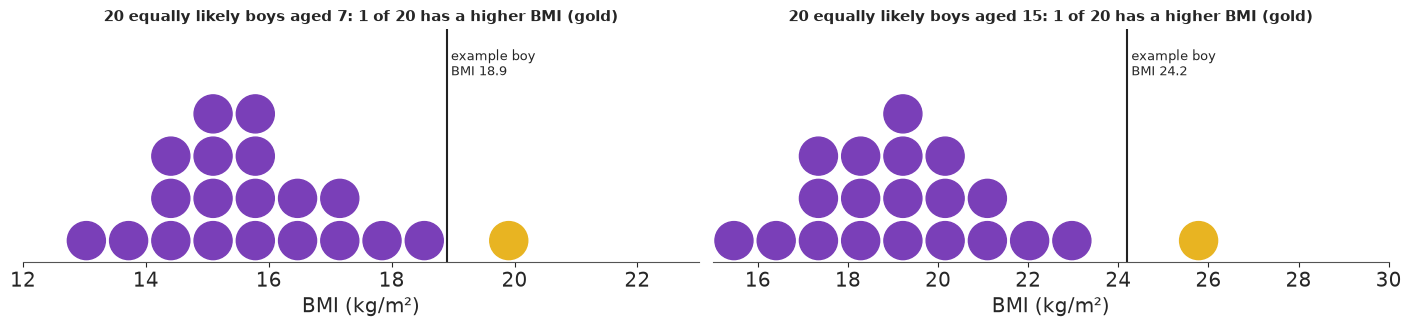

In [24]:
def predictive_draws(age, n_per=1, seed=RANDOM_SEED):
    p = params_at(age)
    u = np.random.default_rng(seed).uniform(size=(n_per, len(p["mu"])))
    return ppf(BEST, u, {k: v[None, :] for k, v in p.items()}).ravel()


def quantile_dotplot(ax, samples, n_dots=20, n_bins=16, xlim=None, color=C_BCT, mark=None):
    q = np.quantile(samples, (np.arange(n_dots) + 0.5) / n_dots)
    edges = np.linspace(*xlim, n_bins + 1)
    w = edges[1] - edges[0]
    heights = np.zeros(n_bins, int)
    for v in q:
        c = int(np.clip(np.digitize(v, edges) - 1, 0, n_bins - 1))
        col = color if (mark is None or v <= mark) else "#e8b422"
        ax.add_patch(Ellipse((edges[c] + w / 2, (heights[c] + 0.5) * w), w * 0.9, w * 0.9, color=col))
        heights[c] += 1
    ax.set(xlim=xlim, ylim=(0, (heights.max() + 1.5) * w), yticks=[], aspect="equal")
    for sp in ("left", "right", "top"):
        ax.spines[sp].set_visible(False)
    return q


fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
DOTS = {}
for ax, e in zip(axes, EXAMPLES):
    ys = predictive_draws(e["age"], n_per=2)
    lo_x, hi_x = np.floor(np.quantile(ys, 0.005)), np.ceil(max(np.quantile(ys, 0.995), e["bmi"] + 1))
    q20 = quantile_dotplot(ax, ys, xlim=(lo_x, hi_x), mark=e["bmi"])
    DOTS[e["age"]] = q20
    ax.axvline(e["bmi"], color=INK, lw=1.5)
    ax.text(e["bmi"], ax.get_ylim()[1] * 0.92, f" example boy\n BMI {e['bmi']}", fontsize=9, va="top")
    ax.set_xlabel("BMI (kg/m²)")
    n_hi = int((q20 > e["bmi"]).sum())
    ax.set_title(f"20 equally likely boys aged {e['age']:g}: {n_hi} of 20 {'has' if n_hi == 1 else 'have'} a higher BMI "
                 "(gold)", fontsize=11)
    print(f"age {e['age']:g}: 20 dots from {q20.min():.1f} to {q20.max():.1f}, median {np.median(ys):.1f}")

**Why it works:** twenty dots can be counted, and "1 of 20 is heavier" is the 95th centile in
the most concrete form possible. The dots also show the shape: the pile leans left and the
heavy boys trail off to the right, more at 15 than at 7. **What it hides:** with only 20 dots
the tail beyond the example boy is one dot; any finer statement ("about 5 in 100") needs the
icon array above.

### 9.4 Watching the distribution grow up (animation)

Press play. Each frame is one age, from 1 month to 21 years; the black curve is how common each
BMI is among boys of that age, the shaded area is the middle half, and the dotted lines are the
3rd and 97th centiles. The thin purple curves are 12 plausible versions of the same curve
(hypothetical outcomes).

In [25]:
FRAME_AGES = np.linspace(0.05**POW, 21.5**POW, 40) ** 3
Bf = basis(FRAME_AGES)
pf_all = model_draws(BEST, FITS[BEST], Bf, n=1000)
pf_med = {k: np.median(v, axis=0) for k, v in pf_all.items()}
HOP = np.random.default_rng(RANDOM_SEED).choice(1000, 12, replace=False)
xs = np.linspace(10, 34, 300)
dens_med = np.exp(logpdf(BEST, xs[:, None], pf_med))                         # (x, frame)
dens_hop = np.exp(logpdf(BEST, xs[:, None, None], {k: v[HOP] for k, v in pf_all.items()}))  # (x, draw, frame)
cent_med = np.stack([ppf(BEST, q, pf_med) for q in (0.03, 0.25, 0.5, 0.75, 0.97)])

fig, ax = plt.subplots(figsize=(9, 4.4), dpi=72)
hop_lines = [ax.plot(xs, dens_hop[:, h, 0], color=C_BCT, lw=0.6, alpha=0.5)[0] for h in range(len(HOP))]
(med_line,) = ax.plot(xs, dens_med[:, 0], color=INK, lw=2)
vl = [ax.axvline(0, color=c, lw=1.2, ls=ls) for c, ls in zip([GREY, C_BCT, INK, C_BCT, GREY], [":", "--", "-", "--", ":"])]
fill = [ax.fill_between(xs, 0, 0)]
ax.set(xlim=(10, 34), ylim=(0, 0.42), xlabel="BMI (kg/m²)", yticks=[], ylabel="how common")
title = ax.set_title("")
note = ax.text(0.98, 0.95, "", transform=ax.transAxes, ha="right", va="top", fontsize=10)
plt.close(fig)


def update(k):
    for h, ln in enumerate(hop_lines):
        ln.set_ydata(dens_hop[:, h, k])
    med_line.set_ydata(dens_med[:, k])
    fill[0].remove()
    inside = (xs >= cent_med[1, k]) & (xs <= cent_med[3, k])
    fill[0] = ax.fill_between(xs[inside], 0, dens_med[inside, k], color=C_BCT, alpha=0.2, lw=0)
    for v_, c_ in zip(vl, cent_med[:, k]):
        v_.set_xdata([c_, c_])
    a = FRAME_AGES[k]
    title.set_text(f"Boys aged {max(a * 12, 1):.0f} month{'s' if a * 12 >= 1.5 else ''}" if a < 2
                   else f"Boys aged {a:.1f} years")
    note.set_text(f"middle half: BMI {cent_med[1, k]:.1f}-{cent_med[3, k]:.1f}\n"
                  f"3 in 100 below {cent_med[0, k]:.1f}, 3 in 100 above {cent_med[4, k]:.1f}\n"
                  "thin lines: 12 plausible versions")
    return hop_lines


anim = animation.FuncAnimation(fig, update, frames=len(FRAME_AGES), interval=300, blit=False)
for k in (0, 20, 39):
    print(f"age {FRAME_AGES[k]:5.2f}: 3rd {cent_med[0, k]:.1f}, median {cent_med[2, k]:.1f}, 97th {cent_med[4, k]:.1f}; "
          f"gap above median {cent_med[4, k] - cent_med[2, k]:.1f} vs below {cent_med[2, k] - cent_med[0, k]:.1f}")
HTML(anim.to_jshtml(default_mode="once"))

age  0.05: 3rd 11.6, median 13.8, 97th 16.4; gap above median 2.6 vs below 2.1
age  4.14: 3rd 13.5, median 15.6, 97th 18.6; gap above median 3.0 vs below 2.1
age 21.50: 3rd 17.8, median 21.9, 97th 27.5; gap above median 5.5 vs below 4.1


**Why it works:** the animation shows the idea behind the whole model - not one number that
changes with age but a whole shape that moves, widens and becomes lopsided. At 1 month the curve
is nearly symmetric (2.6 units from the median to the 97th, 2.1 to the 3rd); at 4 years the
heavy side is already longer (3.0 vs 2.1); at 21 it is wide and lopsided (5.5 vs 4.1). The
thin curves wobble visibly only at the ends of the age range, where the chart is least
certain. **What it hides:** it cannot be printed, and a reader who watches only once misses the
spread of the thin curves; the growth chart in 9.1 is its static partner.

### 9.5 Hover over the chart

For a reader at a screen: hover over any line to get the sentence the chart is supposed to
say, with the likely range of the line at that age. (Interactive in JupyterLab or VS Code;
plotly.js loads from a CDN.)

In [26]:
q_lo, q_md, q_hi = (np.quantile(CB, v, axis=1) for v in (0.05, 0.5, 0.95))   # (centile, age)
fig = go.Figure()
for i, q in enumerate(CENTILES):
    fig.add_trace(go.Scatter(x=np.r_[AGE_GRID, AGE_GRID[::-1]], y=np.r_[q_hi[i], q_lo[i][::-1]], fill="toself",
                             fillcolor="rgba(28,79,148,0.25)", line=dict(width=0), hoverinfo="skip", showlegend=False))
    fig.add_trace(go.Scatter(
        x=AGE_GRID, y=q_md[i], mode="lines", line=dict(color=BLUE_DARK, width=2.5 if q == 0.5 else 1.5),
        name=f"{ordinal(q)} centile", customdata=np.c_[q_lo[i], q_hi[i]],
        hovertemplate=(f"Age %{{x:.1f}} years: {HOVER[q]} have a BMI below %{{y:.1f}}"
                       "<br>(likely somewhere between %{customdata[0]:.1f} and %{customdata[1]:.1f})<extra></extra>")))
fig.update_layout(title="BMI centiles for Dutch boys - hover over a line", xaxis_title="age (years)",
                  yaxis_title="BMI (kg/m²)", template="simple_white", height=480, hovermode="closest")
fig.show()

**Why it works:** the hover text *is* the interpretation ("97 in 100 boys have a BMI below
19.7"), so nobody has to know what a centile is, and the likely range appears only for the
reader who asks. **What it hides:** the static view looks like any growth chart; the uncertainty
bands are barely visible except at the ends.

### 9.6 Export for a web page

In [27]:
def r_(x, nd=2):
    x = np.asarray(x, dtype=float)
    return [None if not np.isfinite(v) else round(float(v), nd) for v in x.ravel()]


EXPORT_Q = [0.05, 0.25, 0.5, 0.75, 0.95]
gi = np.unique(np.r_[np.arange(0, len(AGE_GRID), 3), len(AGE_GRID) - 1])
pB = model_draws(BEST, FITS[BEST], B_GRID, n=1000)
idx = np.random.default_rng(RANDOM_SEED).choice(len(tau_draws), 300, replace=False)
export = {
    "id": "E41",
    "title": "Is my child normal? BMI growth centiles for Dutch boys, with honest uncertainty",
    "data": "Fourth Dutch Growth Study 1996-7: BMI of 7,294 boys aged 0-21 (gamlss.data dbbmi)",
    "model": "Bayesian distributional regression: Box-Cox t distribution (untruncated) whose median M, spread S "
             "and skewness L are P-splines in cube-root age, constant tail degrees of freedom",
    "units": {"age": "years", "bmi": "kg/m^2"},
    "grid": {"age": r_(AGE_GRID[gi], 3), "centiles": r_(CENTILES * 100, 0), "quantiles": EXPORT_Q,
             "values": [[r_(np.quantile(CB[i][:, gi], qq, axis=0), 2) for qq in EXPORT_Q] for i in range(len(CENTILES))],
             "note": "values[c][q][a]: q-quantile over posterior draws of centile c at age a"},
    "lms": {k: [r_(np.quantile(pB[v][:, gi], qq, axis=0), 4) for qq in (0.05, 0.5, 0.95)]
            for k, v in (("M_median", "mu"), ("S_spread", "sigma"), ("L_skewness", "nu"))},
    "tail_df_draws": r_(tau_draws[idx], 1),
    "example_boys": [{"age": e["age"], "bmi": e["bmi"], "note": "hypothetical example boy, not from the data",
                      "pct_boys_heavier_draws": r_(e["heavier"][idx], 2),
                      "pct_boys_heavier_q05_q50_q95": r_(e["q"], 1),
                      "twenty_equally_likely_boys_bmi": r_(DOTS[e["age"]], 1)} for e in EXAMPLES],
    "animation": {"age": r_(FRAME_AGES, 3), "bmi_3_25_50_75_97": [r_(c, 2) for c in cent_med]},
    "model_comparison": [{"model": k, "elpd_loo": round(float(LOO[k].elpd), 0), "se": round(float(LOO[k].se), 0),
                          "pct_below_3rd": round(float((PIT[k] < 0.03).mean() * 100), 1),
                          "pct_above_97th": round(float((PIT[k] > 0.97).mean() * 100), 1)} for k in KEYS],
}
e7, e15 = EXAMPLES
cov_A = coverage_table([KEYS[0]])
export["headlines"] = {
    "chart": "Centile lines are estimates too: the likely range of the 97th-centile line is about "
             f"{np.median(width[4]):.1f} BMI units wide at a typical age, {width[4, j7]:.1f} at age 7 where few boys "
             f"were measured, and {width[4, -1]:.1f} at age 21, the edge of the data; the middle (50th) line is "
             f"within about {np.median(width[2]):.1f}.",
    "example_7": f"An example 7-year-old with BMI {e7['bmi']}: about {e7['q'][1]:.0f} in 100 boys his age have a higher "
                 f"BMI (likely {e7['q'][0]:.1f}-{e7['q'][2]:.1f}).",
    "example_15": f"An example 15-year-old with BMI {e15['bmi']}: about {e15['q'][1]:.0f} in 100 boys his age have a "
                  f"higher BMI (likely {e15['q'][0]:.1f}-{e15['q'][2]:.1f}): the same place on the chart, known more "
                  "precisely, because many more teenagers were measured.",
    "shape": "BMI is not bell-shaped: from school age on, the heavy side stretches much further than the light side, "
             "so a chart built on the average plus or minus a fixed amount puts the wrong boys outside the lines.",
    "naive": f"A chart assuming a bell curve with constant spread put {(PIT[KEYS[0]] > 0.97).mean() * 100:.1f}% of boys "
             f"above its 97th line ({cov_A.loc['17-21 y', (KEYS[0], '% above 97th')]:.0f}% of 17-21-year-olds) and only "
             f"{(PIT[KEYS[0]] < 0.03).mean() * 100:.1f}% below its 3rd line; the final model puts "
             f"{(PIT[BEST] > 0.97).mean() * 100:.1f}% above and {(PIT[BEST] < 0.03).mean() * 100:.1f}% below.",
}
out = Path("../../.scratch/artifact/E41.json")
if not out.parent.exists():  # the build runs in notebooks/examples; fall back to the repo root
    out = Path(".scratch/artifact/E41.json")
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, ensure_ascii=False, separators=(",", ":")))
print(f"wrote {out} ({out.stat().st_size / 1024:.0f} KB)")
print(json.dumps(export["headlines"], indent=1, ensure_ascii=False))

wrote ../../.scratch/artifact/E41.json (20 KB)
{
 "chart": "Centile lines are estimates too: the likely range of the 97th-centile line is about 0.6 BMI units wide at a typical age, 0.9 at age 7 where few boys were measured, and 2.9 at age 21, the edge of the data; the middle (50th) line is within about 0.2.",
 "example_7": "An example 7-year-old with BMI 18.9: about 5 in 100 boys his age have a higher BMI (likely 4.0-6.3).",
 "example_15": "An example 15-year-old with BMI 24.2: about 5 in 100 boys his age have a higher BMI (likely 4.3-5.5): the same place on the chart, known more precisely, because many more teenagers were measured.",
 "shape": "BMI is not bell-shaped: from school age on, the heavy side stretches much further than the light side, so a chart built on the average plus or minus a fixed amount puts the wrong boys outside the lines.",
 "naive": "A chart assuming a bell curve with constant spread put 4.2% of boys above its 97th line (7% of 17-21-year-olds) and only 1.0% belo

The page export above keeps a few hundred draws. The interactive Lumen reports in `reports/`
use the **full posterior** instead: every chain and draw of the fitted parameters, plus the
quantities derived from them over all the draws they were computed on
(`reports/posteriors/E41.nc`, see `reports/README.md`).

In [28]:
from pymc_challenges.export import save_posterior

save_posterior("E41", FITS[BEST], {
    "bmi_centile": (("sample", "centile", "age_years"), np.transpose(CB, (1, 0, 2)),
                    {"centile": np.round(CENTILES * 100).astype(int), "age_years": AGE_GRID}, "BMI kg/m^2",
                    "BMI of the centile line (e.g. centile 97: 97% of boys that age are below it)"),
    "tail_df": (("sample",), tau_draws, {}, "degrees of freedom", "tail heaviness of the Box-Cox t (small = heavy tails)"),
    "pct_boys_heavier": (("sample", "example"), np.column_stack([e["heavier"] for e in EXAMPLES]),
                         {"example": [f"age {e['age']:g}, BMI {e['bmi']:g}" for e in EXAMPLES]}, "percent",
                         "percent of boys the same age with a higher BMI than the example boy"),
}, x_dims=("age_years",));

wrote reports/posteriors/E41.nc: 13 parameters x 4000 draws; 3 derived quantities; 7.4 MB


## 10 · What we learned

- A growth chart is a model of the **whole distribution** at each age, not of the mean. A
  smooth mean with constant noise (model A) put 0-0.5% of babies but 7% of young men above its
  "97th" line; a smooth spread (B) fixed the babies but not the skewness.
- **Distributional regression / GAMLSS**: give every parameter its own smooth function of the
  covariate. Cole & Green's **LMS** method is the **BCCG** distribution with three smooth
  curves; the **Box-Cox t** adds tails. Both likelihoods are a few lines of PyTensor once
  checked (integration, special cases, simulation) and written with branch-free, stable pieces
  ($\log\Phi(b)$ via `erfc`, `expm1` for small $L$).
- **Bayesian P-splines** (B-spline basis + RW2 prior) are the smooth-curve building block;
  with thousands of observations the **centred** form and nutpie's **low-rank** mass matrix
  sample in seconds, where the non-centred form diverged.
- Diagnose centile models with **coverage by age band** and **worm plots**; LOO agreed with
  both (skewness: about +460 elpd; tails: about +18).
- The uncertainty of the **centile lines** is largest for the extreme upper centile, where the
  data are thin (ages 4-9) and at the ends of the age range - exactly where printed charts look
  most authoritative.

## Try it yourself

1. **Smooth tails.** Let the degrees of freedom $\tau$ vary with age (a fourth P-spline) and
   use the exact truncated BCT. Where in childhood do the tails get heavier, and is it worth
   the (large) extra sampling cost? Compare the 99.6th centile.
2. **Heights and heads.** `gamlss.data` also has `dbhh` (height and head circumference of the
   same Dutch boys). Fit model C to head circumference: is L close to 1 (a symmetric trait)?
   What is the smallest model that passes the worm plots?
3. **A second survey.** Growth references change over time (the secular trend). Fit model D to
   a BMI sample from another country or decade and plot the difference of the two 97th
   centiles with its uncertainty: at which ages is the difference larger than the blur?